# Arrears Risk Model — Lewisham

This notebook addresses two objectives:

**1. Understand patterns of vulnerability** across households and small areas in Lewisham:
- How does the proportion of households in arrears vary by IMD decile?
- Which factors are most associated with households being in arrears?
- Identify 3–5 groups of households with different vulnerability profiles and describe them.

**2. Build a predictive model** to identify households at risk of arrears:
- Train a simple model to predict arrears risk.
- If the council could support only 10% of households, how would they be prioritised?

## Contents
1. [Descriptive Overview](#1-descriptive-overview)
2. [IMD Analysis](#2-imd-analysis)
3. [Feature Association Analysis](#3-feature-association-analysis)
4. [Vulnerability Profiling](#4-vulnerability-profiling)
5. [Predictive Models](#5-predictive-models)
6. [Prioritisation](#6-prioritisation)

---
## Data

### Sources

| File | Description |
|---|---|
| `household_data.xlsx` | 17,831 households in Lewisham, 21 variables — demographics, income, housing, benefits, arrears |
| `File_1_IoD2025_Index_of_Multiple_Deprivation.xlsx` | IMD rank and decile for all 33,755 LSOAs in England (IMD25 sheet). Joined on `lsoa21cd`, filters to Lewisham's 175 LSOAs |
| `lewisham_lsoa_to_ward_best-fit_lookup.geojson` | Polygon boundaries for Lewisham's 175 LSOAs, with ward lookup (`wd25cd`, `wd25nm`) — used for choropleth maps |

### Population

The dataset does not cover all Lewisham households. Lewisham has ~130,000 dwellings (Census 2021); the dataset contains 17,831 (~14%). The composition — 92.5% not in work, 61% on Universal Credit, and variables drawn from the benefits system (LHA shortfall, benefit cap, overpayment balance) — indicates this is a subset of households known to the council's benefits/housing system, not the borough population as a whole. This is not stated explicitly in the data and remains an inference. **Any patterns found describe this population, not Lewisham in general.**

### Target variable

`arrears_flag` (binary: 1 = in arrears, 0 = not) is the primary target. `arrears_amount` (continuous, £) is the total amount of arrears across housing and council tax combined — it captures both the flag and severity, and is used as an outcome in some Task 1 analyses. Consistency between the two is verified in Section 1.2.

### Key variable definitions

Most variable names are self-explanatory (`disability`, `fuel_poverty` etc.). The following are less obvious:

- **`tenure_type`**: The household's housing arrangement. Values:
  - *Council tenant* — rents directly from the local authority (Lewisham council); secure tenancy, lowest rents
  - *Social tenant* — rents from a housing association (registered non-profit); similar rents and security to council housing, different landlord
  - *Private tenant* — rents on the private market; typically higher rents, less security
  - *Owner-occupier* — owns the property
  - *Supported housing* — accommodation with wraparound support/care (e.g. for mental health needs, disabilities, domestic abuse); could be council- or housing-association-run
  - *Temporary accommodation* — short-term placement for households accepted as homeless; resident is a licensee not a tenant, intended as transitional
- **`lha_shortfall_weekly`**: Local Housing Allowance (LHA) is the maximum housing benefit paid to private renters. The shortfall is the amount by which actual rent exceeds the LHA rate — the gap the household must cover themselves.
- **`ben_cap_amount`**: The UK government caps total benefits a household can receive. If their benefits would otherwise exceed the cap, this is the amount deducted — a direct income reduction.
- **`income_after_costs`**: Estimated household income after essential costs. The task brief says "essential costs" without specifying what's included — likely dominated by rent given this population, but could also include utilities, council tax, etc. Can be negative when costs exceed income.
- **`overpayment_balance`**: Outstanding balance of benefits previously overpaid to the household, which they are required to repay — an ongoing financial drag.
- **`ctc_takeup`**: Whether the household claims Child Tax Credit — a legacy benefit (being replaced by Universal Credit). Very low takeup (0.4%) in this data because most claimants have migrated to UC.
- **`whd_takeup`**: Whether the household receives the Warm Home Discount — a £150/year rebate on energy bills for low-income households.
- **`fsm_eligible`**: Whether the household contains children eligible for Free School Meals — a widely used proxy for child poverty, based on receiving UC below a certain income threshold.

### IMD

The **Index of Multiple Deprivation** is an area-level (LSOA) variable, not a household-level one — every household in the same LSOA receives the same rank and decile. It captures "where you live" rather than "who you are."

IMD is a composite of seven domains: 
- Income (22.5%), 
- Employment (22.5%), 
- Education (13.5%), 
- Health (13.5%), 
- Crime (9.3%), 
- Barriers to Housing & Services (9.3%), and 
- Living Environment (9.3%). 

Income and Employment together account for 45% of the score and are based on benefit receipt and worklessness — largely the same signals the household-level data already captures directly. This is relevant for interpreting the (lack of) correlation between IMD and arrears within this population (Section 2).

**Deciles**: the IMD ranks all 33,755 LSOAs in England from 1 (most deprived) to 33,755 (least deprived) and divides them into 10 equal groups. Decile 1 = most deprived 10% of English LSOAs; decile 10 = least deprived 10%.

In [698]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

from pathlib import Path
PLOTS_DIR = Path('results/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

---
## 1. Descriptive Overview

Basic portrait of the dataset: variable distributions, arrears rate, and severity. Goal is to understand the data before any analysis and flag anomalies.

### 1.0 Load data

In [699]:
df = pd.read_excel('data/household_data.xlsx')

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
df.head(10)

Rows: 17,831  |  Columns: 21


,reference,lsoa21cd,ward,household_type,age_bracket,tenure_type,economic_status,disability,monthly_rent,lha_shortfall_weekly,ben_cap_amount,universal_credit,income_after_costs,fuel_poverty,food_poverty,overpayment_balance,arrears_amount,arrears_flag,ctc_takeup,whd_takeup,fsm_eligible
0,ID00001,E01003189,Bellingham,Single,55-59,Social tenant,Not in work,Disabled,545.31,0.00000,0.00,Yes,585.27,Yes,No,0.00,0.00,No,No,Yes,No
1,ID00002,E01003189,Bellingham,Lone parent,35-39,Private tenant,Not in work,Not disabled,1346.28,0.00000,20.32,Yes,269.95,No,No,0.00,0.00,No,No,Yes,No
2,ID00003,E01003189,Bellingham,Couple with children,50-54,Council tenant,Not in work,Disabled,655.50,0.00000,0.00,Yes,1370.70,Yes,No,0.00,0.00,No,No,Yes,Yes
3,ID00004,E01003189,Bellingham,Single,55-59,Private tenant,Not in work,Disabled,1291.98,0.00000,0.00,Yes,552.42,No,No,0.00,277.87,Yes,No,Yes,No
4,ID00005,E01003189,Bellingham,Single,85-89,Owner-occupier,Not in work,Disabled,0.00,0.00000,0.00,No,1026.42,No,No,0.00,0.00,No,No,Yes,No
5,ID00006,E01003189,Bellingham,Single,60-64,Social tenant,Not in work,Disabled,611.73,0.00000,0.00,Yes,684.62,No,No,0.00,0.00,No,No,Yes,No
6,ID00007,E01003189,Bellingham,Lone parent,45-49,Social tenant,Not in work,Disabled,868.18,0.00000,0.00,Yes,1495.47,No,No,0.00,81.00,Yes,No,Yes,Yes
7,ID00008,E01003189,Bellingham,Single,60-64,Social tenant,Not in work,Disabled,798.46,0.00000,0.00,Yes,794.23,No,No,25709.97,2832.93,Yes,No,Yes,No
8,ID00009,E01003189,Bellingham,Single,60-64,Social tenant,Not in work,Disabled,573.69,0.00000,0.00,Yes,372.50,Yes,No,0.00,0.00,No,No,Yes,No
9,ID00010,E01003189,Bellingham,Single,50-54,Private tenant,In work,Not disabled,1575.00,121.16317,0.00,Yes,-65.53,No,Yes,0.00,0.00,No,No,Yes,No


### 1.1 Missing values

In [700]:
missing = df.isnull().sum()
missing = missing[missing > 0].rename('missing_count').to_frame()
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)

if missing.empty:
    print('No missing values.')
else:
    display(missing)

,missing_count,missing_pct
ben_cap_amount,1,0.01


### 1.2 Recode binary columns and verify arrears consistency

Recode all Yes/No columns to 0/1. Then verify that arrears_flag and arrears_amount are consistent: all flagged households should have a non-zero arrears amount and vice versa.

In [701]:
binary_cols = [
    'disability', 'fuel_poverty', 'food_poverty',
    'universal_credit', 'ctc_takeup', 'whd_takeup', 'fsm_eligible'
]
yn_map = {'Yes': 1, 'No': 0}

df['arrears_flag'] = df['arrears_flag'].map(yn_map)
df['disability'] = df['disability'].map({'Disabled': 1, 'Not disabled': 0})
df['economic_status'] = df['economic_status'].map({'In work': 1, 'Not in work': 0})
for col in binary_cols:
    if col != 'disability':
        df[col] = df[col].map(yn_map)

flagged_zero_amount   = ((df['arrears_flag'] == 1) & (df['arrears_amount'] == 0)).sum()
unflagged_nonzero_amt = ((df['arrears_flag'] == 0) & (df['arrears_amount'] > 0)).sum()

print(f'Flagged in arrears but arrears_amount = 0 : {flagged_zero_amount}')
print(f'Not flagged but arrears_amount > 0       : {unflagged_nonzero_amt}')

Flagged in arrears but arrears_amount = 0 : 0
Not flagged but arrears_amount > 0       : 0


### 1.3 Join IMD data

Both `household_data.xlsx` and the IMD file share the `lsoa21cd` (LSOA code) column.

In [702]:
imd_raw = pd.read_excel('data/File_1_IoD2025_Index_of_Multiple_Deprivation.xlsx',
                        sheet_name='IMD25')
imd = imd_raw.rename(columns={
    'LSOA code (2021)': 'lsoa21cd',
    'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)': 'imd_rank',
    'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA': 'imd_decile',
})[['lsoa21cd', 'imd_rank', 'imd_decile']]

df = df.merge(imd, on='lsoa21cd', how='left')

print(f'IMD missing for households in Lewisham data: {df["imd_rank"].isna().sum()}')
print(f'Lewisham LSOAs in Lewisham data: {df["lsoa21cd"].nunique()}')
print(f'IMD decile range: {df["imd_decile"].min()} \u2013 {df["imd_decile"].max()}')

IMD missing for households in Lewisham data: 0
Lewisham LSOAs in Lewisham data: 175
IMD decile range: 1 – 9


### 1.4 Summary table

For each variable: type, possible values (or range), count of non-null values, and mean/median for continuous variables or proportion = 1 for binary variables.

In [703]:
continuous_cols = [
    'monthly_rent', 'lha_shortfall_weekly', 'ben_cap_amount',
    'income_after_costs', 'overpayment_balance', 'arrears_amount',
    'imd_rank'
]
categorical_cols = [
    'household_type', 'age_bracket', 'tenure_type', 'economic_status', 'ward'
]
ordinal_cols = ['imd_decile']
id_cols = ['reference', 'lsoa21cd']
high_cardinality = ['ward', 'age_bracket']

rows = []

for col in id_cols:
    rows.append({
        'variable': col, 'type': 'identifier',
        'possible_values': f'{df[col].nunique():,} unique',
        'n_non_null': int(df[col].notna().sum()),
        'mean': '', 'median': '', 'min': '', 'max': '',
        'std': '', 'cv': '',
        'proportion_or_mode': ''
    })

for col in continuous_cols:
    lo, hi = df[col].min(), df[col].max()
    rows.append({
        'variable': col, 'type': 'continuous',
        'possible_values': f'\u00a3{lo:,.2f} to \u00a3{hi:,.2f}',
        'n_non_null': int(df[col].notna().sum()),
        'mean': round(float(df[col].mean()), 2),
        'median': round(float(df[col].median()), 2),
        'min': round(float(df[col].min()), 2),
        'max': round(float(df[col].max()), 2),
        'std': round(float(df[col].std()), 2),
        'cv': f"{abs(df[col].std() / df[col].mean()):.2f}" if df[col].mean() != 0 else 'n/a',
        'proportion_or_mode': ''
    })

for col in binary_cols + ['arrears_flag']:
    rows.append({
        'variable': col, 'type': 'binary',
        'possible_values': '0, 1',
        'n_non_null': int(df[col].notna().sum()),
        'mean': '', 'median': '', 'min': '', 'max': '',
        'std': '', 'cv': '',
        'proportion_or_mode': f"{df[col].mean()*100:.1f}% = 1"
    })

for col in categorical_cols:
    mode = df[col].mode()[0]
    mode_pct = (df[col] == mode).mean() * 100
    if col in high_cardinality:
        pv = f'{df[col].nunique()} unique'
    else:
        unique = sorted(df[col].dropna().unique(), key=str)
        pv = ', '.join(str(v) for v in unique)
    rows.append({
        'variable': col, 'type': 'categorical',
        'possible_values': pv,
        'n_non_null': int(df[col].notna().sum()),
        'mean': '', 'median': '', 'min': '', 'max': '',
        'std': '', 'cv': '',
        'proportion_or_mode': f"mode: {mode} ({mode_pct:.1f}%)"
    })

for col in ordinal_cols:
    lo, hi = int(df[col].min()), int(df[col].max())
    mode = int(df[col].mode()[0])
    mode_pct = (df[col] == mode).mean() * 100
    rows.append({
        'variable': col, 'type': 'ordinal',
        'possible_values': f'{lo} to {hi} (1 = most deprived)',
        'n_non_null': int(df[col].notna().sum()),
        'mean': round(float(df[col].mean()), 2),
        'median': round(float(df[col].median()), 2),
        'min': lo, 'max': hi,
        'std': round(float(df[col].std()), 2),
        'cv': f"{abs(df[col].std() / df[col].mean()):.2f}" if df[col].mean() != 0 else 'n/a',
        'proportion_or_mode': f"mode: {mode} ({mode_pct:.1f}%)"
    })

summary_df = pd.DataFrame(rows).set_index('variable')

with pd.option_context('display.max_colwidth', None):
    display(summary_df)

,type,possible_values,n_non_null,mean,median,min,max,std,cv,proportion_or_mode
variable,,,,,,,,,,
reference,identifier,"17,831 unique",17831,,,,,,,
lsoa21cd,identifier,175 unique,17831,,,,,,,
monthly_rent,continuous,"£-143.64 to £5,598.15",17831,873.48,645.66,-143.64,5598.15,746.37,0.85,
lha_shortfall_weekly,continuous,"£0.00 to £1,141.97",17831,4.12,0.0,0.0,1141.97,26.55,6.44,
ben_cap_amount,continuous,£0.00 to £672.62,17830,1.57,0.0,0.0,672.62,14.55,9.25,
income_after_costs,continuous,"£-4,697.05 to £10,315.85",17831,731.36,667.24,-4697.05,10315.85,709.76,0.97,
overpayment_balance,continuous,"£0.00 to £68,409.04",17831,153.81,0.0,0.0,68409.04,1453.25,9.45,
arrears_amount,continuous,"£0.00 to £26,910.14",17831,440.01,0.0,0.0,26910.14,1327.02,3.02,
imd_rank,continuous,"£454.00 to £27,854.00",17831,11580.17,10666.0,454.0,27854.0,5750.27,0.50,


### 1.5 Distributions of categorical and binary variables

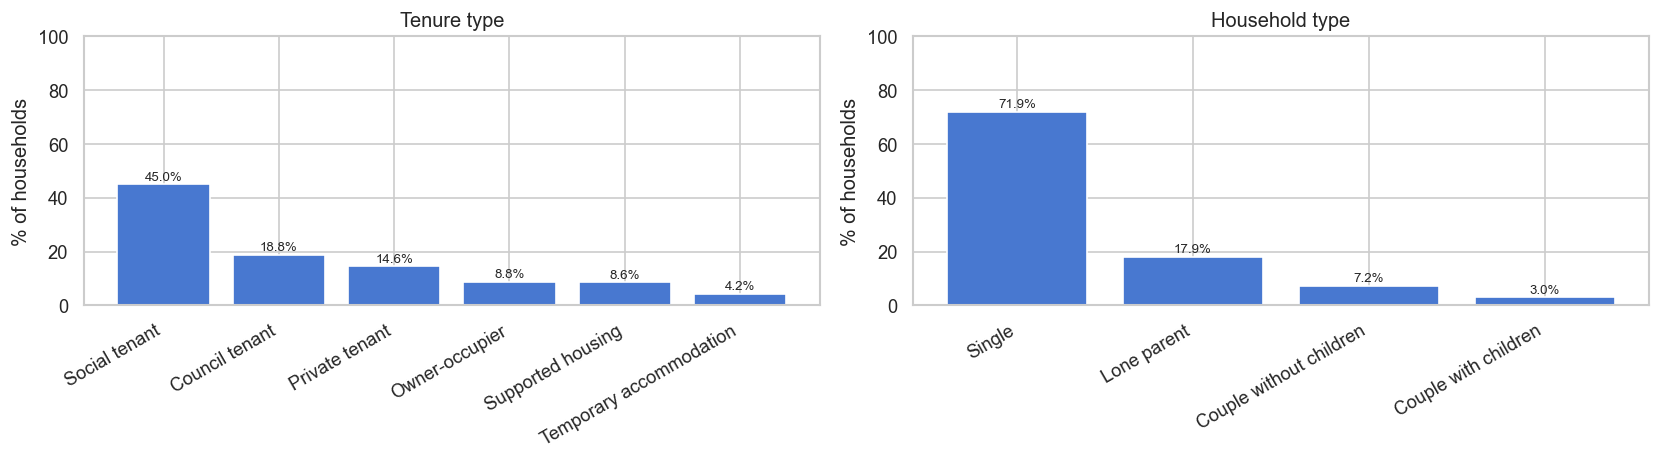

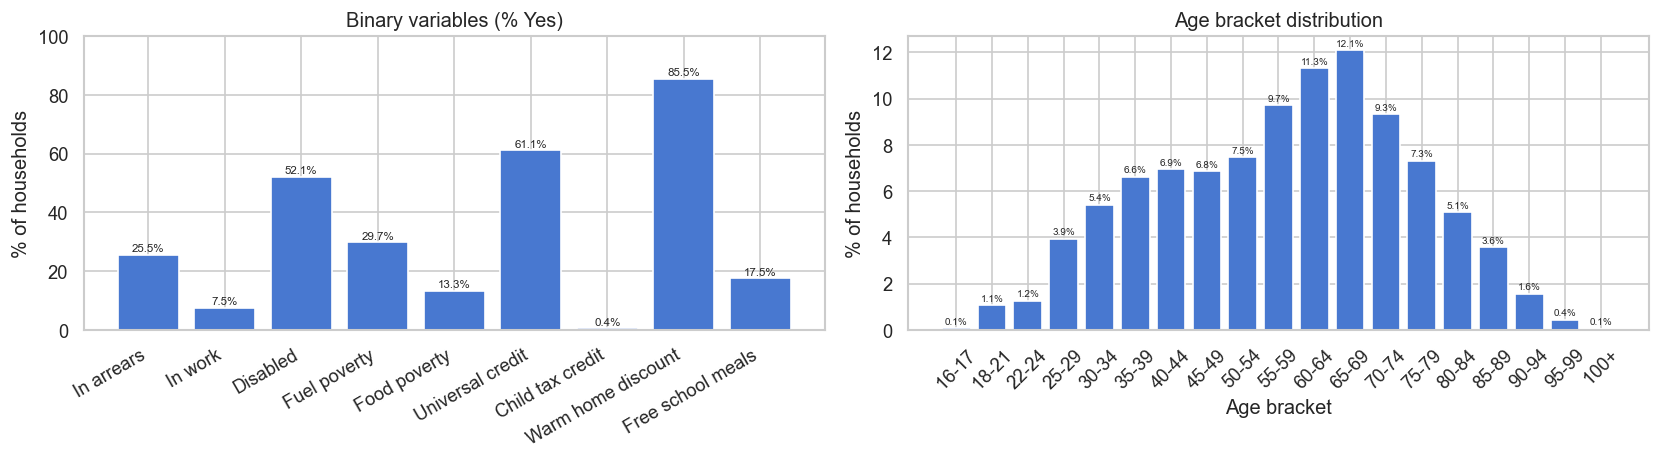

In [704]:
cat_plot_cols = [
    ('tenure_type',     'Tenure type'),
    ('household_type',  'Household type'),
]

bin_plot_cols = [
    ('arrears_flag',     'In arrears'),
    ('economic_status',  'In work'),
    ('disability',       'Disabled'),
    ('fuel_poverty',     'Fuel poverty'),
    ('food_poverty',     'Food poverty'),
    ('universal_credit', 'Universal credit'),
    ('ctc_takeup',       'Child tax credit'),
    ('whd_takeup',       'Warm home discount'),
    ('fsm_eligible',     'Free school meals'),
]


FULL_WIDTH = 14

# Figure 1: tenure type + household type
fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 4))
for ax, (col, label) in zip(axes, cat_plot_cols):
    props = df[col].value_counts(normalize=True).sort_values(ascending=False) * 100
    bars = ax.bar(props.index, props.values)
    ax.set_title(label)
    ax.set_ylabel('% of households')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=30)
    for tick in ax.get_xticklabels():
        tick.set_ha('right')
    for bar, val in zip(bars, props.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '1_5_tenure_household.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: binary variables + age bracket
fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 4))

# Left: binary variables
bin_labels = [label for _, label in bin_plot_cols]
bin_values = []
for col, _ in bin_plot_cols:
    bin_values.append(float(df[col].mean() * 100))

bars = axes[0].bar(bin_labels, bin_values)
axes[0].set_title('Binary variables (% Yes)')
axes[0].set_ylabel('% of households')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=30)
for tick in axes[0].get_xticklabels():
    tick.set_ha('right')
for bar, val in zip(bars, bin_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

# Right: age bracket
age_order = sorted(df['age_bracket'].unique(),
                   key=lambda x: int(x.replace('+', '').split('-')[0]))
age_counts = df['age_bracket'].value_counts(normalize=True).reindex(age_order) * 100

bars = axes[1].bar(age_counts.index, age_counts.values)
axes[1].set_title('Age bracket distribution')
axes[1].set_xlabel('Age bracket')
axes[1].set_ylabel('% of households')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, age_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=6)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '1_5_binary_and_age.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.6 Distributions of continuous variables

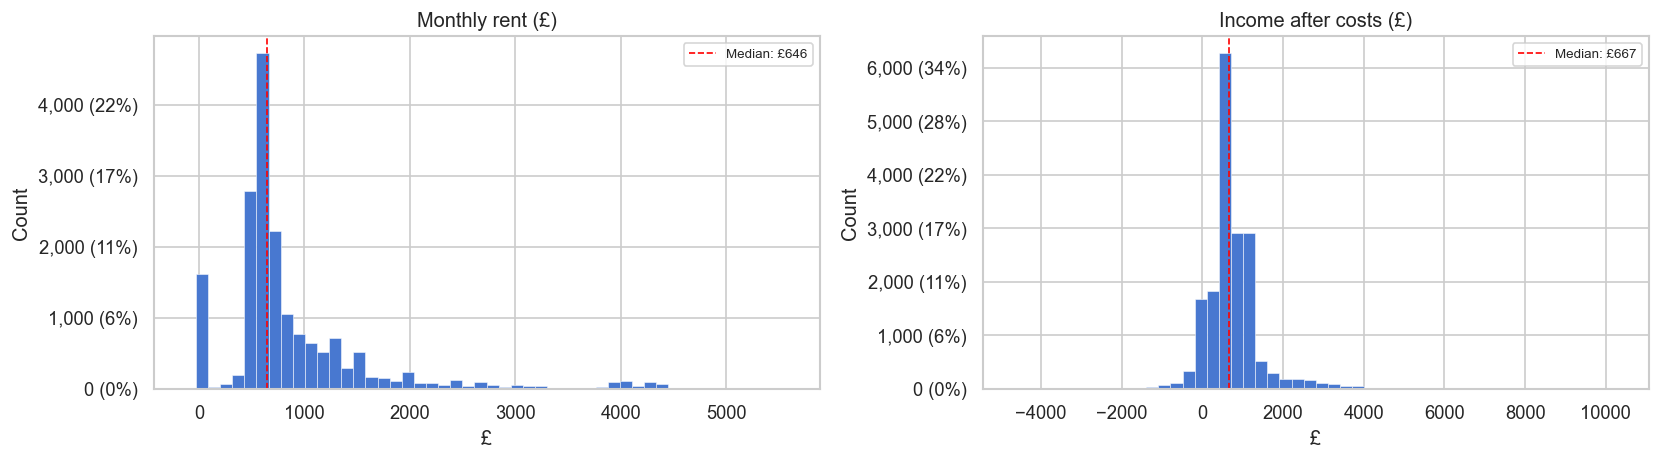

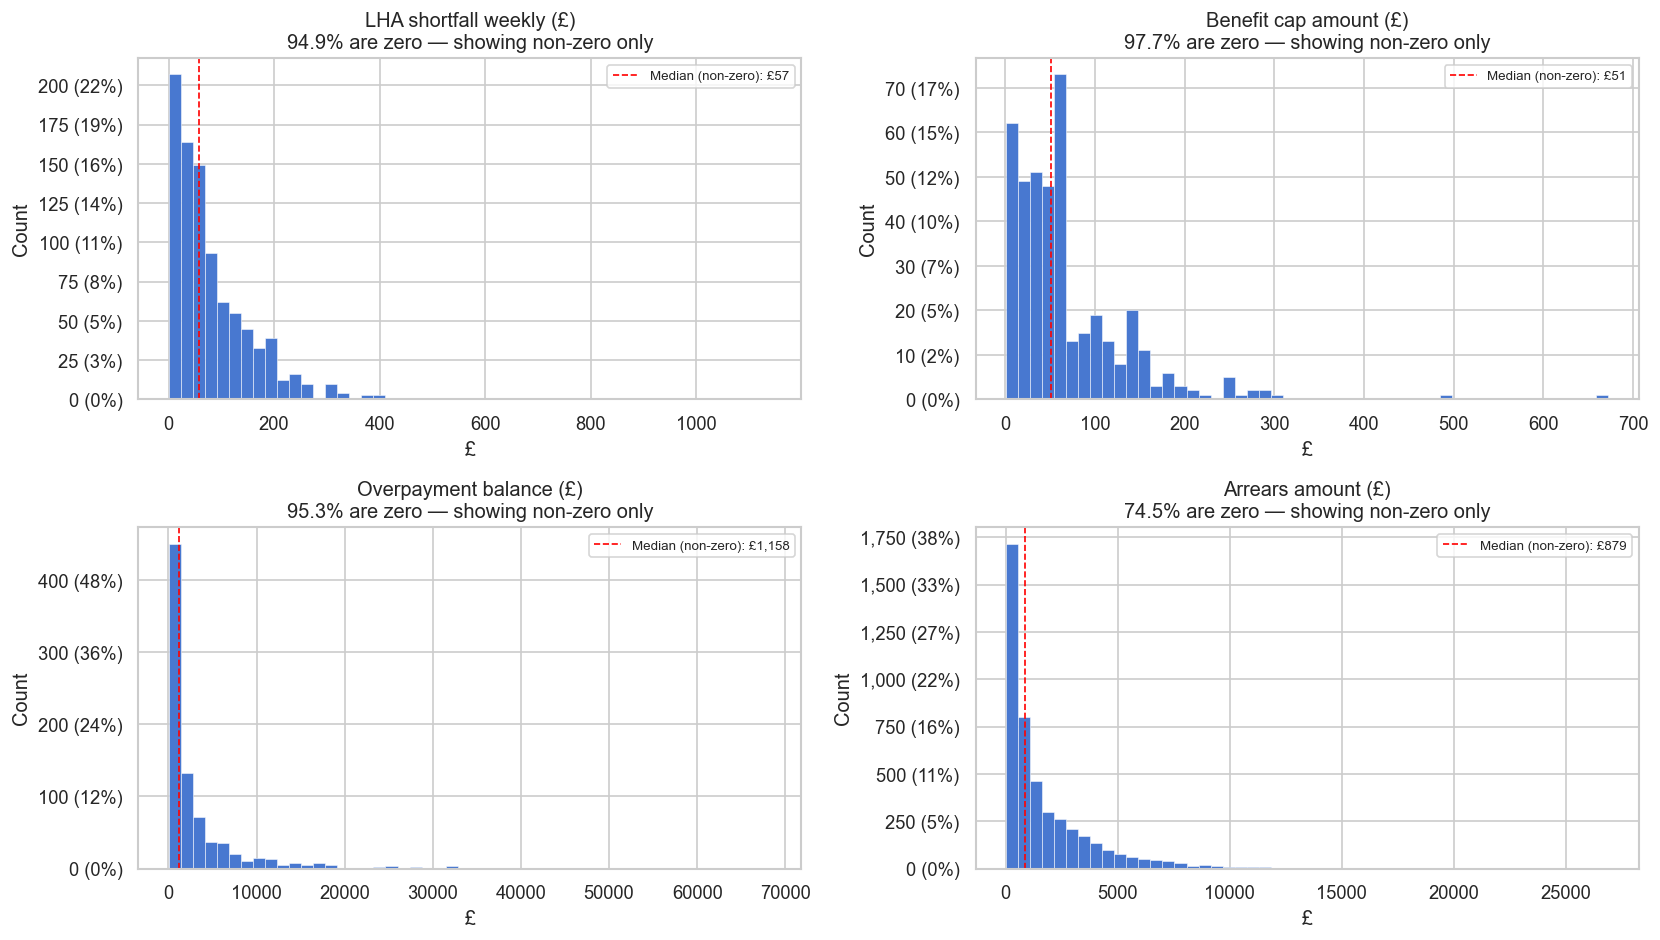

In [705]:
FULL_WIDTH = 14
n_total = len(df)

zero_heavy = ['lha_shortfall_weekly', 'ben_cap_amount', 'overpayment_balance', 'arrears_amount']

from matplotlib.ticker import FuncFormatter

def make_count_fmt(n_ref):
    """Format tick as count (pct%) relative to n_ref."""
    def fmt(x, pos):
        return f'{int(x):,} ({x / n_ref * 100:.0f}%)'
    return FuncFormatter(fmt)

# Figure 1: monthly_rent and income_after_costs (not zero-dominated)
fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 4))
for ax, (col, label) in zip(axes, [
    ('monthly_rent', 'Monthly rent (£)'),
    ('income_after_costs', 'Income after costs (£)')
]):
    data = df[col].dropna()
    ax.hist(data, bins=50, edgecolor='white', linewidth=0.3)
    ax.set_title(label)
    ax.set_xlabel('£')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(make_count_fmt(n_total))
    ax.axvline(float(data.median()), color='red', linestyle='--',
               linewidth=1, label=f'Median: £{float(data.median()):,.0f}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '1_6_rent_income.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: zero-heavy variables — % zero + non-zero distribution
fig, axes = plt.subplots(2, 2, figsize=(FULL_WIDTH, 8))
axes = axes.flatten()
labels = {
    'lha_shortfall_weekly': 'LHA shortfall weekly (£)',
    'ben_cap_amount': 'Benefit cap amount (£)',
    'overpayment_balance': 'Overpayment balance (£)',
    'arrears_amount': 'Arrears amount (£)',
}
for ax, col in zip(axes, zero_heavy):
    data = df[col].dropna()
    n_zero = (data == 0).sum()
    pct_zero = n_zero / len(data) * 100
    nonzero = data[data > 0]
    ax.hist(nonzero, bins=50, edgecolor='white', linewidth=0.3)
    ax.set_title(f'{labels[col]}\n{pct_zero:.1f}% are zero — showing non-zero only')
    ax.set_xlabel('£')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(make_count_fmt(len(nonzero)))
    ax.axvline(float(nonzero.median()), color='red', linestyle='--',
               linewidth=1, label=f'Median (non-zero): £{float(nonzero.median()):,.0f}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '1_6_zero_heavy.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.7 IMD decile distribution across Lewisham LSOAs

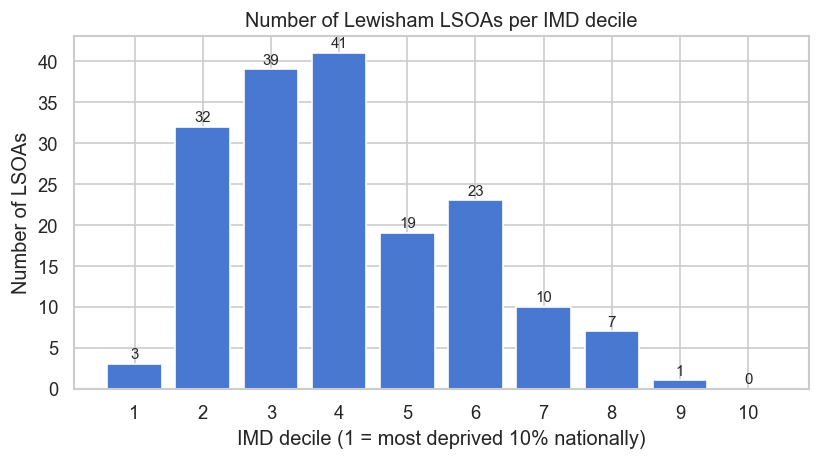

In [706]:
FULL_WIDTH = 14

lsoa_imd = df.groupby('lsoa21cd')['imd_decile'].first().value_counts().reindex(range(1, 11), fill_value=0)

fig, ax = plt.subplots(figsize=(FULL_WIDTH / 2, 4))
bars = ax.bar(lsoa_imd.index, lsoa_imd.values)
ax.set_title('Number of Lewisham LSOAs per IMD decile')
ax.set_xlabel('IMD decile (1 = most deprived 10% nationally)')
ax.set_ylabel('Number of LSOAs')
ax.set_xticks(range(1, 11))
for bar, val in zip(bars, lsoa_imd.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '1_7_imd_decile_lsoa_counts.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.8 Key takeaways

- **Not the general population**: 17,831 households = ~14% of Lewisham's ~130,000 dwellings. With 92.5% not in work and 61% on Universal Credit, this is a benefits-system cohort.
- **One in four in arrears**: 25.5% arrears rate.
- **Dominated by single-person households** (71.9%), with an older age profile (mode: 65–69). The distribution skews towards older age groups — a large share of this population is older adults on benefits.
- **Tenure split**: ~45% social tenants, meaningful shares of council tenants and private tenants, smaller groups in supported housing and temporary accommodation.
- **Most financial stress variables are zero for most people**: LHA shortfall, benefit cap, and overpayment balance are zero for the majority — but when non-zero, the amounts can be substantial. The affected minorities are potentially very vulnerable.
- **WHD takeup is 85.5%** — most households in this dataset are low-income and qualify.
- **CTC at 0.4%** — effectively a dead variable (legacy benefit replaced by UC).
- **Negative income_after_costs exists** — some households' essential costs exceed their income entirely.
- **Lewisham is heavily deprived**: most LSOAs fall into the most deprived national deciles, with few or none in the least deprived. This is an area-level backdrop, not a household-level variable.
- **Data quality is clean**: only 1 missing value across 17,831 x 21. Arrears flag and amount are perfectly consistent.

---
## 2. IMD Analysis

How does the proportion of households in arrears vary by deprivation? Two outcome measures are reported throughout: **arrears rate** (% of households with arrears_amount > 0) and **mean arrears amount** — capturing prevalence and severity respectively.

### 2.1 LSOA-level scatterplot: IMD rank vs arrears rate

Each of the 175 LSOAs is one point. Spearman correlation is used because IMD rank is ordinal.

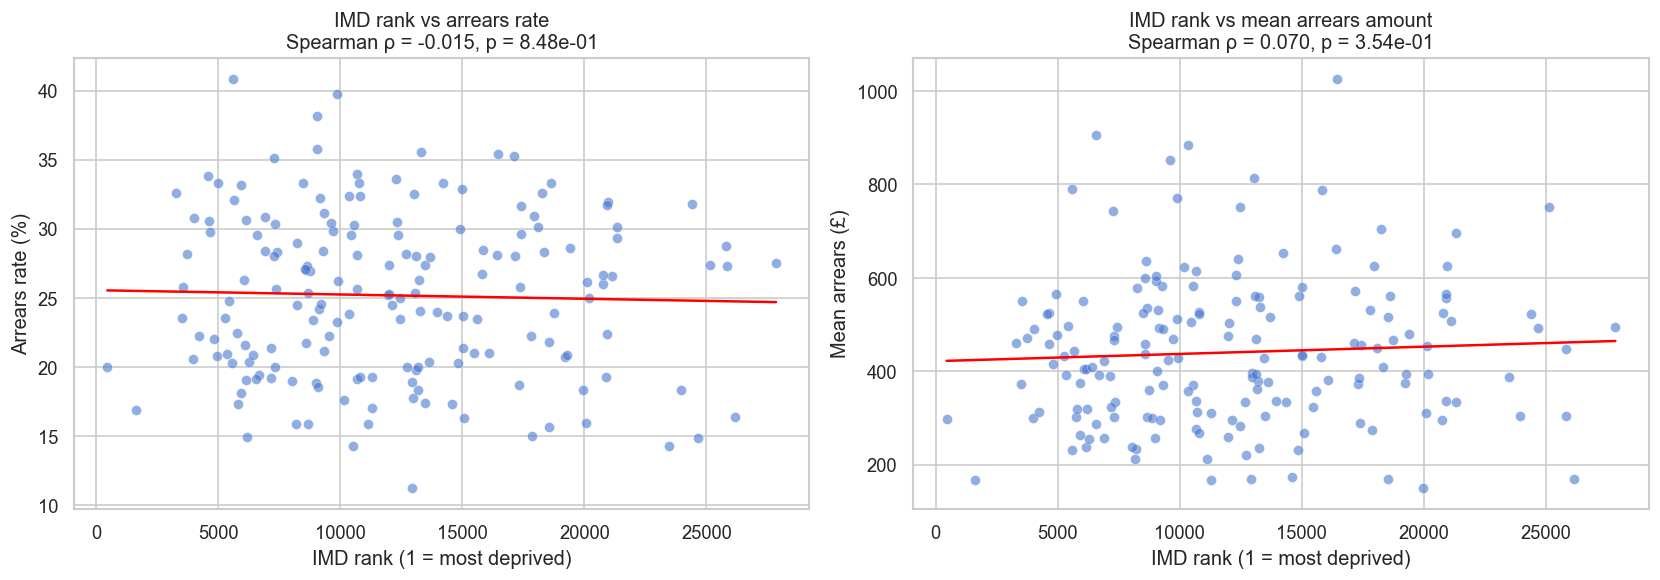

In [707]:
from scipy.stats import spearmanr


lsoa_stats = df.groupby('lsoa21cd').agg(
    imd_rank=('imd_rank', 'first'),
    imd_decile=('imd_decile', 'first'),
    n_households=('arrears_flag', 'count'),
    arrears_rate=('arrears_flag', 'mean'),
    mean_arrears=('arrears_amount', 'mean'),
).reset_index()
lsoa_stats['arrears_rate_pct'] = lsoa_stats['arrears_rate'] * 100

# Spearman correlation: IMD rank vs arrears rate
rho_rate, p_rate = spearmanr(lsoa_stats['imd_rank'], lsoa_stats['arrears_rate'])
rho_amt, p_amt = spearmanr(lsoa_stats['imd_rank'], lsoa_stats['mean_arrears'])

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 5))

# Left: IMD rank vs arrears rate
axes[0].scatter(lsoa_stats['imd_rank'], lsoa_stats['arrears_rate_pct'],
                alpha=0.6, edgecolors='white', linewidth=0.3)
z = np.polyfit(lsoa_stats['imd_rank'], lsoa_stats['arrears_rate_pct'], 1)
x_line = np.linspace(lsoa_stats['imd_rank'].min(), lsoa_stats['imd_rank'].max(), 100)
axes[0].plot(x_line, np.polyval(z, x_line), color='red', linewidth=1.5)
axes[0].set_title(f'IMD rank vs arrears rate\nSpearman ρ = {rho_rate:.3f}, p = {p_rate:.2e}')
axes[0].set_xlabel('IMD rank (1 = most deprived)')
axes[0].set_ylabel('Arrears rate (%)')

# Right: IMD rank vs mean arrears amount
axes[1].scatter(lsoa_stats['imd_rank'], lsoa_stats['mean_arrears'],
                alpha=0.6, edgecolors='white', linewidth=0.3)
z = np.polyfit(lsoa_stats['imd_rank'], lsoa_stats['mean_arrears'], 1)
axes[1].plot(x_line, np.polyval(z, x_line), color='red', linewidth=1.5)
axes[1].set_title(f'IMD rank vs mean arrears amount\nSpearman ρ = {rho_amt:.3f}, p = {p_amt:.2e}')
axes[1].set_xlabel('IMD rank (1 = most deprived)')
axes[1].set_ylabel('Mean arrears (£)')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '2_1_imd_vs_arrears_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

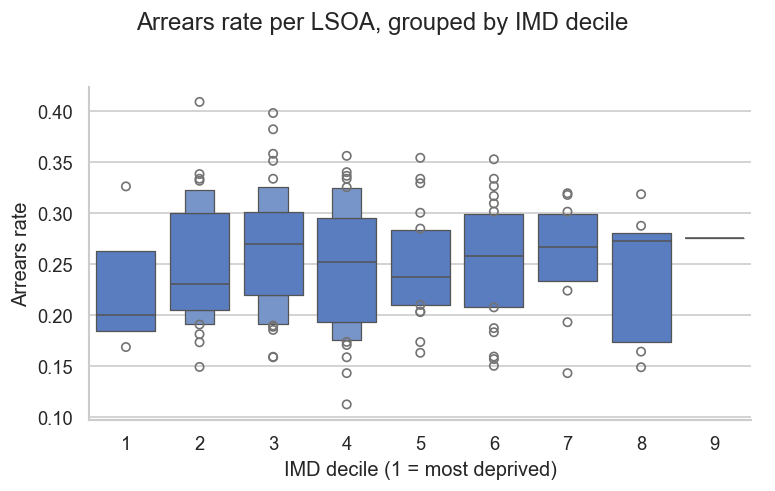

In [708]:
g = sns.catplot(data=lsoa_stats, x="imd_decile", y="arrears_rate",
                kind="boxen", height=4, aspect=1.6)
g.set_axis_labels("IMD decile (1 = most deprived)", "Arrears rate")
g.fig.suptitle("Arrears rate per LSOA, grouped by IMD decile", y=1.02)
g.fig.tight_layout()
g.savefig(PLOTS_DIR / '2_1b_imd_decile_arrears_rate.png', dpi=150, bbox_inches='tight')

### 2.2 Maps: arrears rate and IMD decile by LSOA

Side-by-side choropleth maps. If the spatial patterns look similar, this is direct visual evidence of the deprivation–arrears relationship.

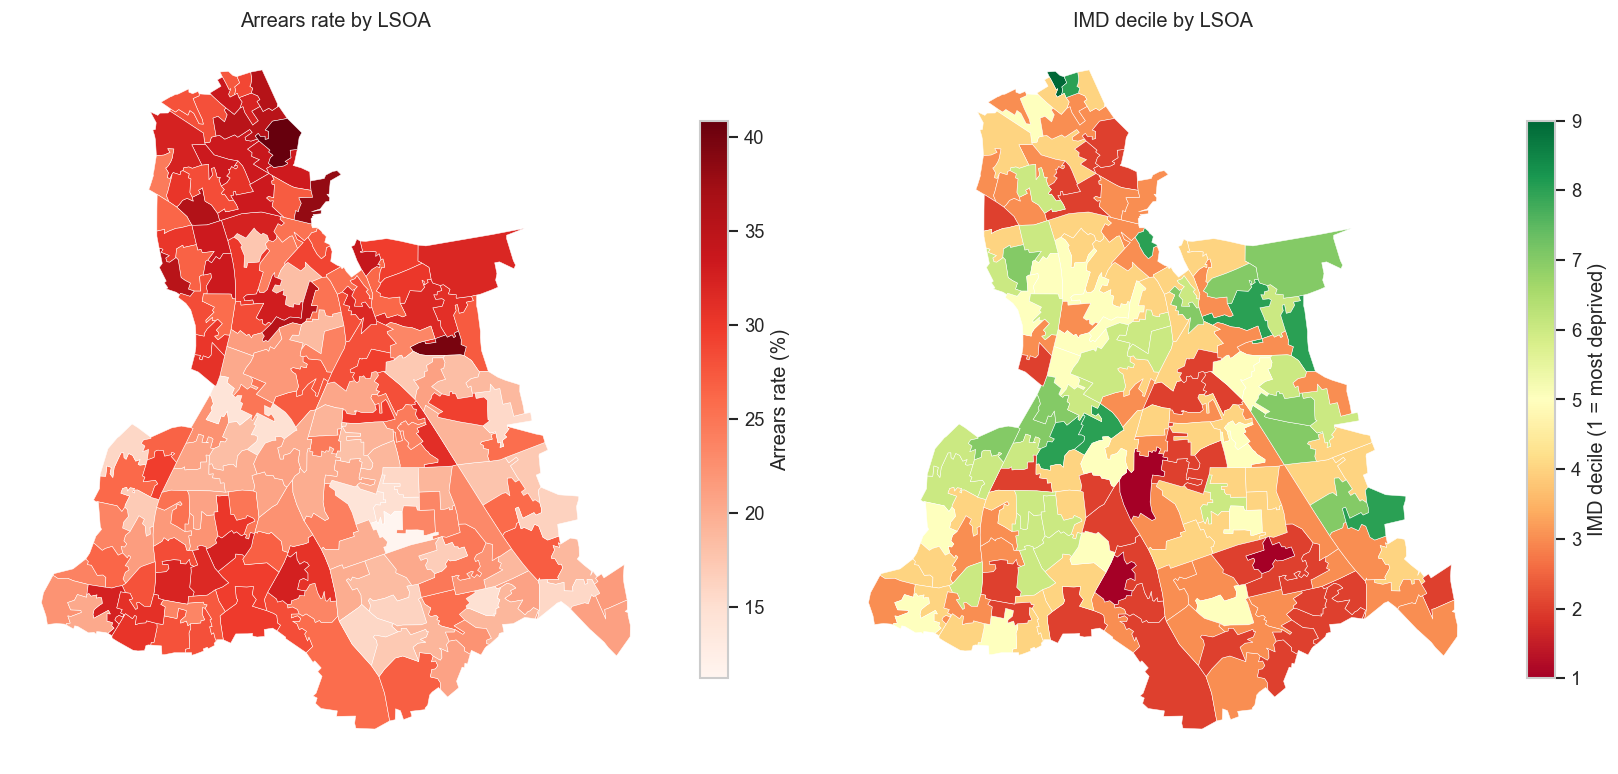

In [709]:
import geopandas as gpd

gdf = gpd.read_file('data/lewisham_lsoa_to_ward_best-fit_lookup.geojson')
gdf = gdf.merge(lsoa_stats, on='lsoa21cd', how='left')

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 7))

# Left: arrears rate
gdf.plot(column='arrears_rate_pct', ax=axes[0], legend=True,
         legend_kwds={'label': 'Arrears rate (%)', 'shrink': 0.7},
         cmap='Reds', edgecolor='white', linewidth=0.3)
axes[0].set_title('Arrears rate by LSOA')
axes[0].axis('off')

# Right: IMD decile (1 = most deprived → dark)
gdf.plot(column='imd_decile', ax=axes[1], legend=True,
         legend_kwds={'label': 'IMD decile (1 = most deprived)', 'shrink': 0.7},
         cmap='RdYlGn', edgecolor='white', linewidth=0.3)
axes[1].set_title('IMD decile by LSOA')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '2_2_maps_arrears_imd.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Key takeaways

- **What IMD measures**: the Index of Multiple Deprivation is a composite of seven domains:
  - Income (22.5%)
  - Employment (22.5%)
  - Education (13.5%)
  - Health (13.5%)
  - Crime (9.3%)
  - Barriers to Housing & Services (9.3%)
  - Living Environment (9.3%)

  Notably, Income and Employment together make up 45% of the score and are based on benefit receipt and worklessness — the same signals our household-level data already captures directly.
- **Area-level deprivation does not differentiate arrears risk within this population.** The scatterplots show near-zero Spearman correlations between IMD rank and both arrears rate and mean arrears amount. The maps confirm this visually: the spatial pattern of arrears rates does not align with the spatial pattern of IMD deciles. This is consistent with the dataset being a benefits-system cohort: the biggest components of IMD (income and employment deprivation) have almost no variation left within a population that is 92.5% not in work and 61% on UC. The remaining domains (health, education, crime, environment, housing access) might still vary across LSOAs, but they are less directly connected to arrears and make up the other 55% of the score.
- **But both variables show spatial clustering individually.** Arrears rates cluster spatially (nearby LSOAs tend to have similar rates), and IMD deciles cluster spatially too — the two patterns simply don't overlap. Whatever local factor is driving the spatial clustering in arrears, it is not captured by IMD.
- **Implication**: targeting the most deprived LSOAs would not be a good proxy for targeting arrears risk among an already deprived population.

---
## 3. Feature Association Analysis

Which factors are most associated with arrears? Two approaches: (A) a Spearman correlation heatmap for a broad overview across all features, and (B) domain-driven deep dives into the most relevant variables.

### 3.1 Spearman correlation heatmap

Pairwise Spearman rank correlations across all numeric, binary, and ordinal features. The primary purpose here is to check for **multicollinearity** between predictors and to provide a broad sanity check — not to draw conclusions about individual predictors' importance.

Spearman requires values to have a meaningful ordering. Binary variables (0/1) are included because with only two levels the direction of association is unambiguous — though the correlation magnitude is structurally capped below what a continuous variable could achieve. Note that the *sign* of a binary variable's correlation depends on the coding convention (which level is 1); it is only interpretable with reference to that coding, not in isolation. Nominal categoricals with 3+ unordered levels (`tenure_type`, `household_type`, `ward`) are excluded because any numeric encoding would be arbitrary and produce meaningless correlations — these are addressed in the deep dives (3.2).

Spearman also has known limitations with zero-inflated distributions (most values identical → many tied ranks → attenuated correlations). The deep dives in 3.2 and 3.3 are where the substantive insights come from.

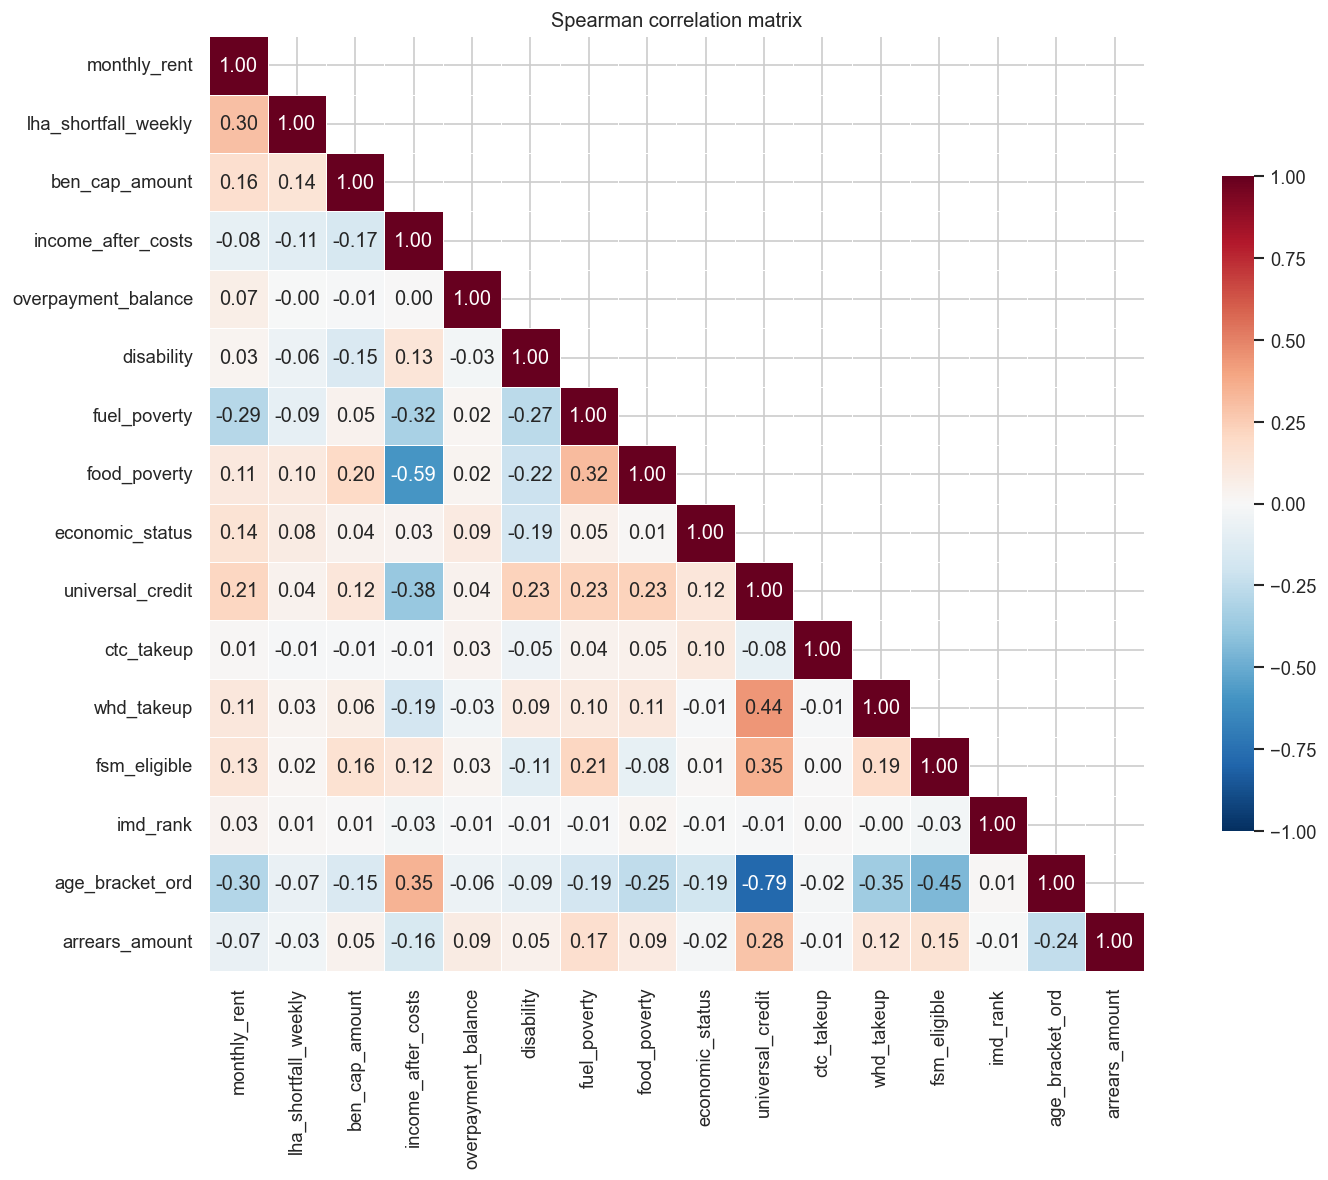

Spearman correlations with arrears_amount:

universal_credit        0.283642
age_bracket_ord        -0.244950
fuel_poverty            0.168364
income_after_costs     -0.160008
fsm_eligible            0.146513
whd_takeup              0.118437
food_poverty            0.086813
overpayment_balance     0.085092
monthly_rent           -0.073738
disability              0.048304
ben_cap_amount          0.045913
lha_shortfall_weekly   -0.034960
economic_status        -0.018491
ctc_takeup             -0.012363
imd_rank               -0.006266


In [710]:
FULL_WIDTH = 14

# Ordinal encoding for age_bracket
age_order = sorted(df['age_bracket'].unique(), key=lambda x: int(x.split('-')[0].replace('+', '')))
df['age_bracket_ord'] = df['age_bracket'].map({v: i for i, v in enumerate(age_order)})

# Numeric, binary, and ordinal columns for heatmap
heatmap_cols = [
    'monthly_rent', 'lha_shortfall_weekly', 'ben_cap_amount',
    'income_after_costs', 'overpayment_balance',
    'disability', 'fuel_poverty', 'food_poverty',
    'economic_status', 'universal_credit', 'ctc_takeup', 'whd_takeup', 'fsm_eligible',
    'imd_rank', 'age_bracket_ord',
    'arrears_amount',
]

corr = df[heatmap_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(FULL_WIDTH, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Spearman correlation matrix')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '3_1_spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlations with arrears_amount, sorted
arrears_corr = corr['arrears_amount'].drop('arrears_amount').sort_values(key=abs, ascending=False)
print('Spearman correlations with arrears_amount:\n')
print(arrears_corr.to_string())

### 3.2 Deep dives: categorical/binary variables

Arrears rate and mean arrears amount per category. Variable selection for the following barplots: 
- `tenure_type` and `household_type` are nominal categoricals excluded from the heatmap and need separate treatment. 
- `universal_credit` (0.28) and `age_bracket` (-0.25) showed the strongest correlations with arrears. 
- `fuel_poverty`, `whd_takeup`, and `fsm_eligible` are also relevant benefit/poverty indicators. 
- `economic_status` showed a weak correlation which is surprising - included to double check.

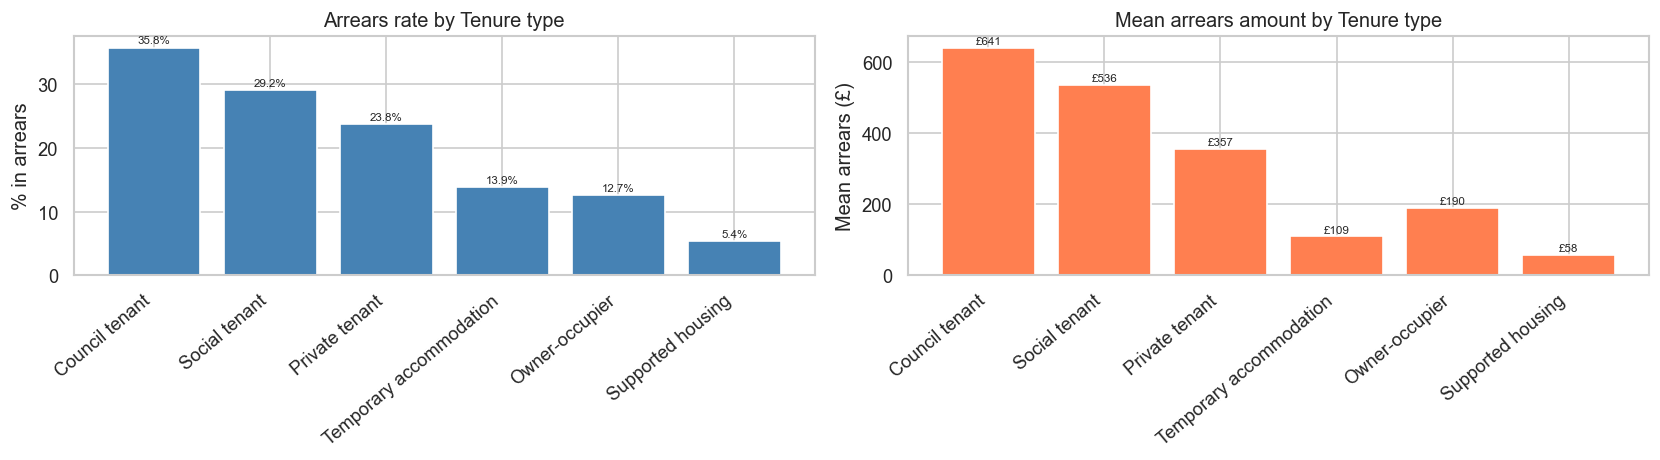

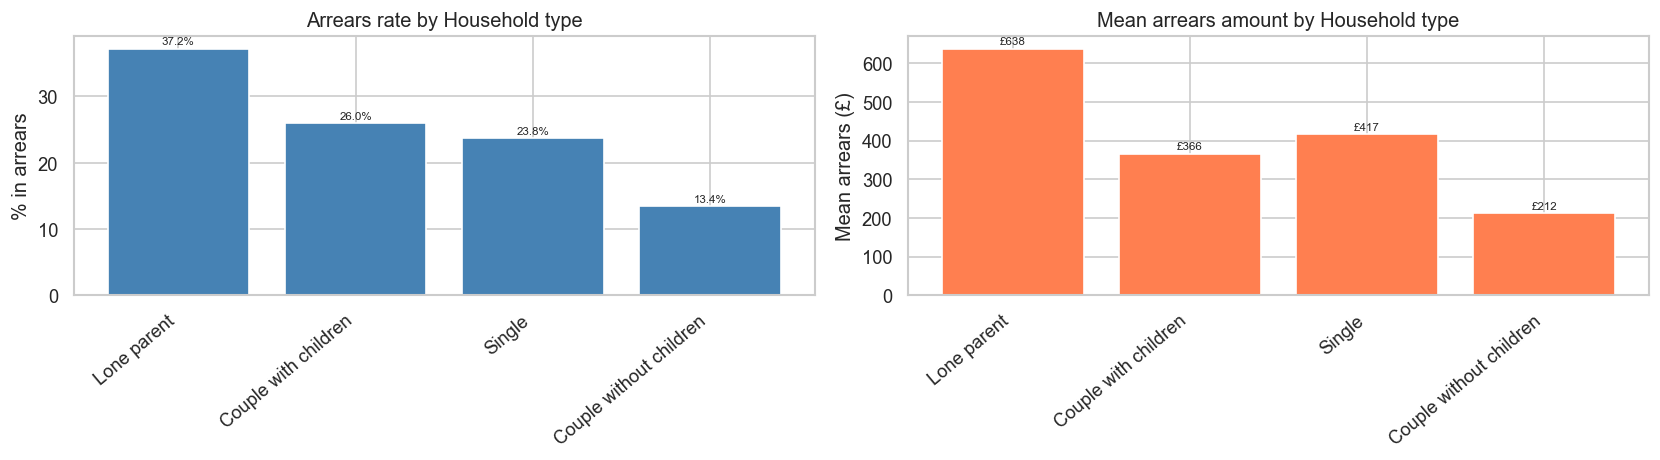

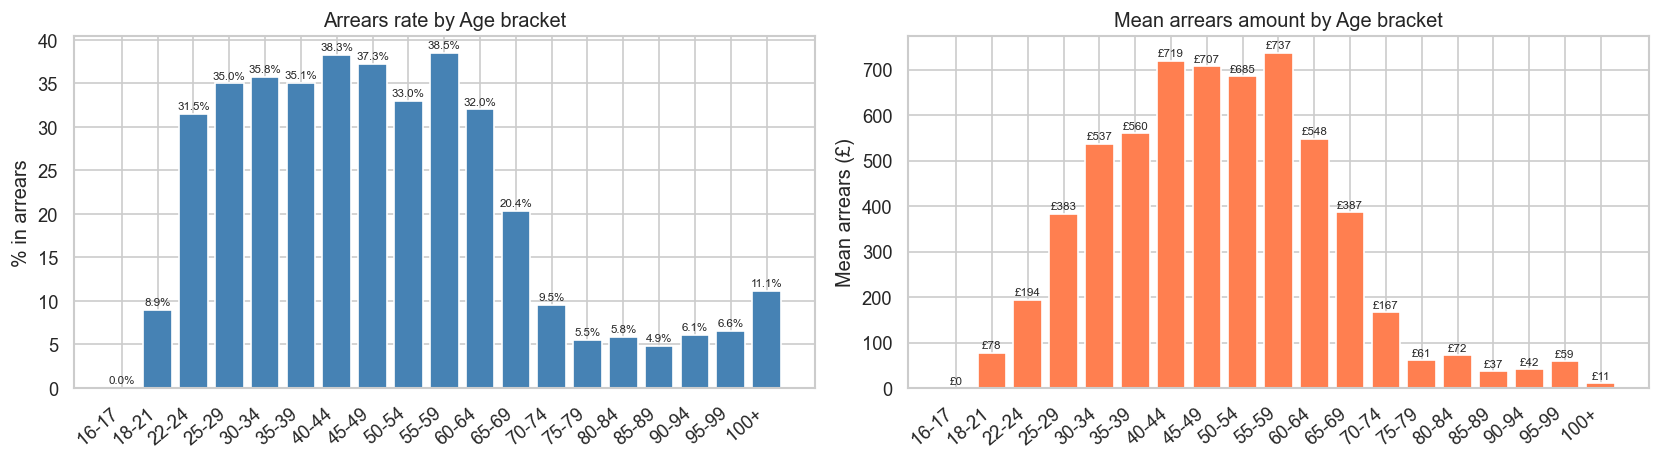

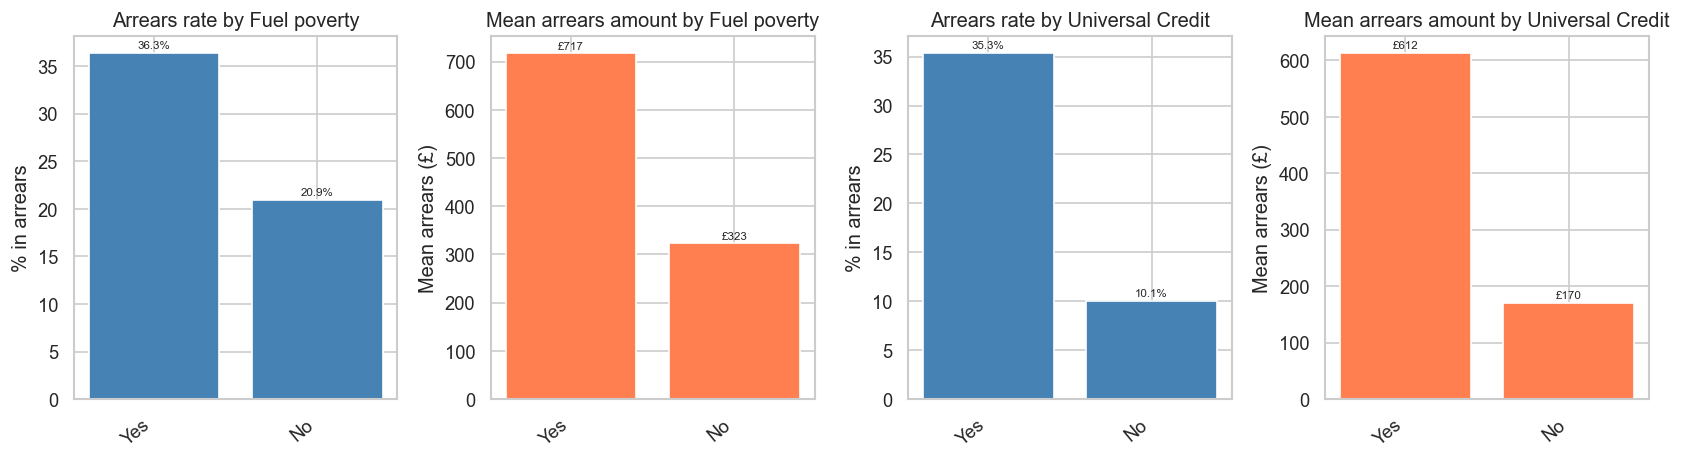

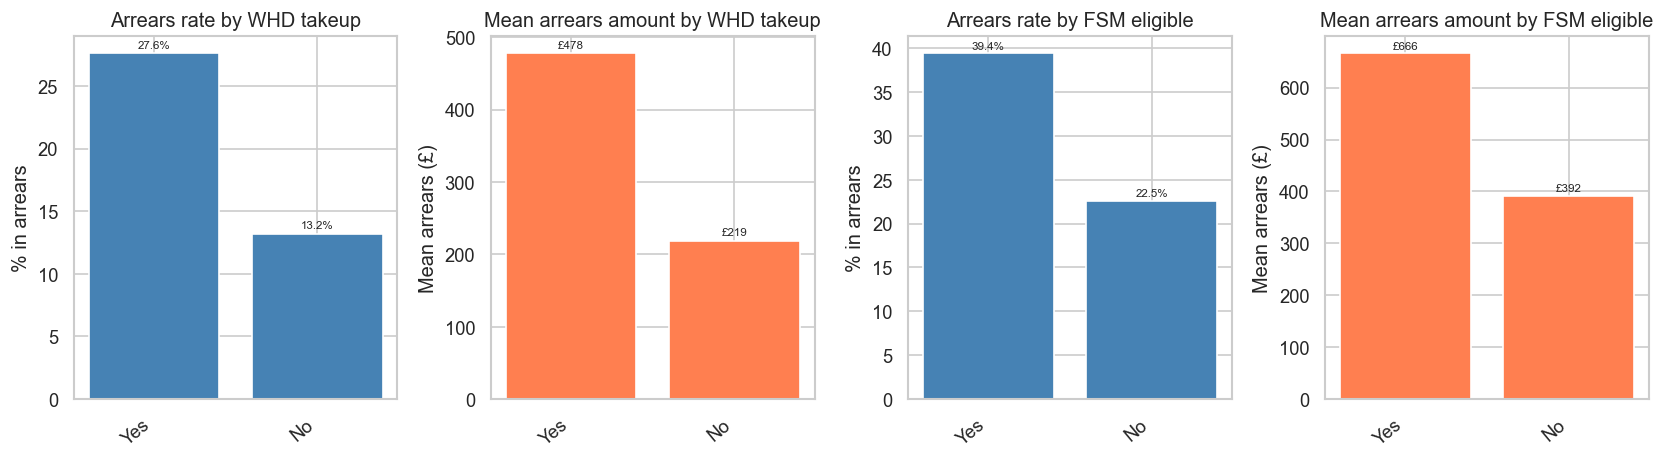

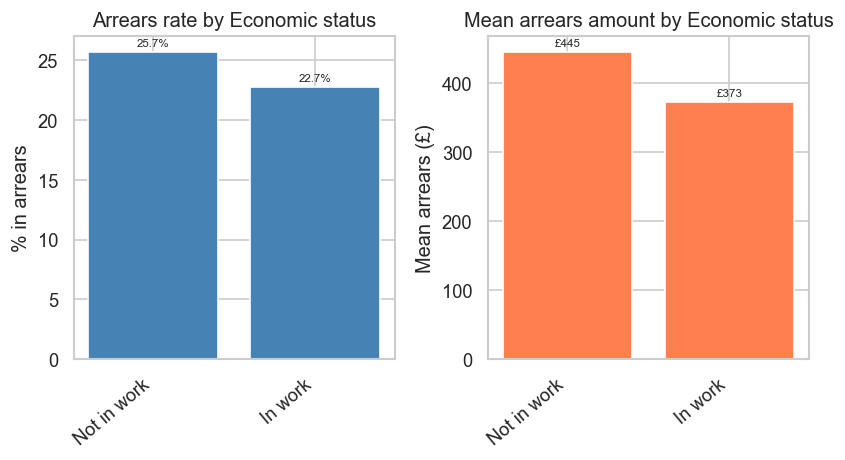

In [711]:
FULL_WIDTH = 14
HALF_WIDTH = FULL_WIDTH / 2

def plot_cat_deep(ax_rate, ax_mean, col, label, df):
    """Plot arrears rate and mean arrears for a single categorical/binary variable."""
    # Use original labels for binary variables
    if col in ['economic_status', 'fuel_poverty', 'universal_credit', 'whd_takeup', 'fsm_eligible']:
        if col == 'economic_status':
            display_s = df[col].map({1: 'In work', 0: 'Not in work'})
        else:
            display_s = df[col].map({1: 'Yes', 0: 'No'})
    else:
        display_s = df[col]

    grp = df.assign(_display=display_s).groupby('_display').agg(
        n=('arrears_flag', 'count'),
        arrears_rate=('arrears_flag', 'mean'),
        mean_arrears=('arrears_amount', 'mean'),
    )
    grp['arrears_rate_pct'] = grp['arrears_rate'] * 100

    if col == 'age_bracket':
        grp = grp.reindex(sorted(grp.index,
                   key=lambda x: int(x.replace('+', '').split('-')[0])))
    else:
        grp = grp.sort_values('arrears_rate_pct', ascending=False)

    bars = ax_rate.bar(grp.index, grp['arrears_rate_pct'], color='steelblue')
    ax_rate.set_title(f'Arrears rate by {label}')
    ax_rate.set_ylabel('% in arrears')
    ax_rate.tick_params(axis='x', rotation=40)
    for tick in ax_rate.get_xticklabels():
        tick.set_ha('right')
    for bar, val in zip(bars, grp['arrears_rate_pct']):
        ax_rate.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

    bars = ax_mean.bar(grp.index, grp['mean_arrears'], color='coral')
    ax_mean.set_title(f'Mean arrears amount by {label}')
    ax_mean.set_ylabel('Mean arrears (£)')
    ax_mean.tick_params(axis='x', rotation=40)
    for tick in ax_mean.get_xticklabels():
        tick.set_ha('right')
    for bar, val in zip(bars, grp['mean_arrears']):
        ax_mean.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                     f'£{val:,.0f}', ha='center', va='bottom', fontsize=7)

# --- Full-width variables (1x2 each) ---
full_width_vars = [
    ('tenure_type',    'Tenure type'),
    ('household_type', 'Household type'),
    ('age_bracket',    'Age bracket'),
]

for col, label in full_width_vars:
    fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 4))
    plot_cat_deep(axes[0], axes[1], col, label, df)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'3_2_deep_dive_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- Binary variable pairs (1x4 each, two variables side by side) ---
binary_pairs = [
    [('fuel_poverty',    'Fuel poverty'),   ('universal_credit', 'Universal Credit')],
    [('whd_takeup',      'WHD takeup'),     ('fsm_eligible',     'FSM eligible')],
]

for (col1, label1), (col2, label2) in binary_pairs:
    fig, axes = plt.subplots(1, 4, figsize=(FULL_WIDTH, 4))
    plot_cat_deep(axes[0], axes[1], col1, label1, df)
    plot_cat_deep(axes[2], axes[3], col2, label2, df)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'3_2_deep_dive_{col1}_{col2}.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- Economic status (half-width, alone) ---
fig, axes = plt.subplots(1, 2, figsize=(HALF_WIDTH, 4))
plot_cat_deep(axes[0], axes[1], 'economic_status', 'Economic status', df)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '3_2_deep_dive_economic_status.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Deep dives: continuous variables

Distribution of key continuous variables in arrears vs non-arrears households (overlapping histograms).

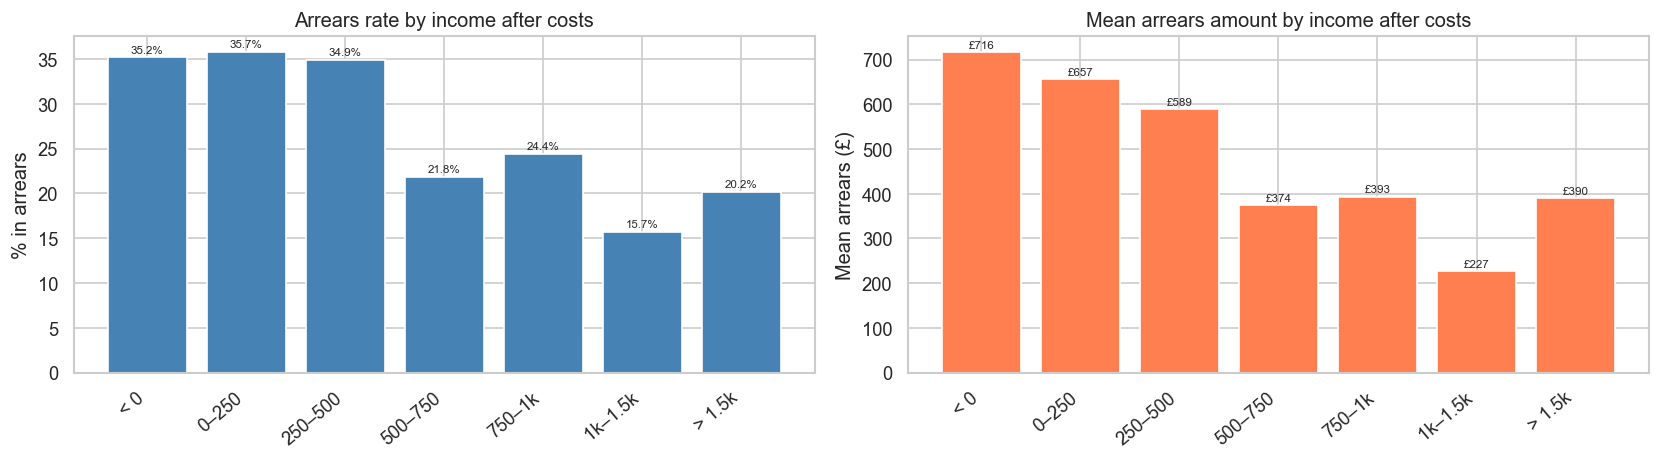

In [712]:
FULL_WIDTH = 14

# Bin income_after_costs into groups
bins = [-float('inf'), 0, 250, 500, 750, 1000, 1500, float('inf')]
labels = ['< 0', '0–250', '250–500', '500–750', '750–1k', '1k–1.5k', '> 1.5k']
df['income_bin'] = pd.cut(df['income_after_costs'], bins=bins, labels=labels)

grp = df.groupby('income_bin', observed=False).agg(
    n=('arrears_flag', 'count'),
    arrears_rate=('arrears_flag', 'mean'),
    mean_arrears=('arrears_amount', 'mean'),
)
grp['arrears_rate_pct'] = grp['arrears_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 4))

# Left: arrears rate
bars = axes[0].bar(grp.index, grp['arrears_rate_pct'], color='steelblue')
axes[0].set_title('Arrears rate by income after costs')
axes[0].set_ylabel('% in arrears')
axes[0].tick_params(axis='x', rotation=40)
for tick in axes[0].get_xticklabels():
    tick.set_ha('right')
for bar, val in zip(bars, grp['arrears_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

# Right: mean arrears amount
bars = axes[1].bar(grp.index, grp['mean_arrears'], color='coral')
axes[1].set_title('Mean arrears amount by income after costs')
axes[1].set_ylabel('Mean arrears (£)')
axes[1].tick_params(axis='x', rotation=40)
for tick in axes[1].get_xticklabels():
    tick.set_ha('right')
for bar, val in zip(bars, grp['mean_arrears']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'£{val:,.0f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '3_3_income_bins.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['income_bin'], inplace=True)

### 3.4 Key takeaways

- **No single feature is a strong predictor of arrears on its own.** The strongest Spearman correlation with `arrears_amount` is `universal_credit` at 0.28, followed by `age_bracket` at -0.25 — all others are weaker. Whether this reflects genuinely weak associations or is partly an artefact of Spearman's limitations with binary and zero-inflated variables is unclear. Interestingly, economic status is not a predictor.
- **There is notable multicollinearity between some predictors:**
  - `universal_credit` ↔ `age_bracket` at -0.79 (older households on legacy benefits rather than UC)
  - `income_after_costs` ↔ `food_poverty` at -0.59
  - Several pairs in the 0.3–0.45 range (e.g., `fsm_eligible` ↔ `age_bracket`, `universal_credit` ↔ `whd_takeup`)

  This is relevant for logistic regression, where correlated predictors inflate standard errors and make individual coefficients unreliable. Tree-based models are less affected.
- **The Spearman correlation heatmap is useful for detecting multicollinearity between predictors and sanity checks**; individual correlations with arrears should be interpreted with caution given the attenuating effects of binary (e.g., `disability`, `fuel_poverty`) and zero-inflated (e.g., `lha_shortfall_weekly`, `ben_cap_amount`) variables, where most values are identical and produce many tied ranks.

- Higher arrears rates and amounts are associated with:
  - **Tenure**: council tenants, social tenants, private tenants
  - **Household type**: lone parents, couples with children, single people
  - **Age**: younger households, up to around 65
  - **Benefit/poverty indicators**: fuel poverty, Universal Credit, WHD takeup
  - **Income**: income after costs below £500


---
## 4. Vulnerability Profiling

Identify 3–5 groups of households with shared characteristics using **k-prototypes** clustering — an algorithm that handles mixed continuous and categorical data natively. Arrears rate and mean arrears amount are reported as properties of each cluster after the fact, not used to form them.

**Features used for clustering:**
- Continuous (standardised):
  - `monthly_rent`
  - `lha_shortfall_weekly`
  - `ben_cap_amount`
  - `income_after_costs`
  - `overpayment_balance`
- Categorical:
  - `tenure_type`
  - `household_type`
  - `age_bracket`
  - `economic_status`
  - `disability`
  - `fuel_poverty`
  - `food_poverty`
  - `universal_credit`
  - `ctc_takeup`
  - `whd_takeup`
  - `fsm_eligible`

**Excluded from clustering:**
- Identifiers: `reference`, `lsoa21cd`, `ward`
- Outcome variables: `arrears_flag`, `arrears_amount`

**Why IMD rank and decile are excluded:** IMD showed near-zero correlation with arrears in this population (Section 2), so it carries no useful signal for distinguishing vulnerability. What remains is purely geographic information — IMD is an area-level variable where all households in the same LSOA share the same rank, and including it would push co-located households toward the same cluster. Since these profiles are meant to describe types of household vulnerability, not types of neighbourhood, IMD is excluded from clustering. IMD rank and decile are reported in the summary table as descriptors of where each cluster lives, but do not influence cluster formation.

**Gamma parameter**: k-prototypes computes distances between households using both continuous and categorical features. The gamma parameter controls their relative weight — higher gamma means categorical mismatches count for more.

With the default gamma (inferred from data), continuous distances dominated. Several continuous features in this dataset have extreme outliers (e.g. overpayment balance up to £68,409 against a mean of £154, LHA shortfall up to £1,142 against a mean of £4). Even after standardisation, these values are many standard deviations from the mean, producing large continuous distances that dwarfed categorical mismatches. The result: one giant cluster containing ~85% of households, and a few tiny clusters (< 1% each) that were simply groups of continuous-variable outliers — not meaningful vulnerability profiles.

Gamma = 3.0 rebalances this by giving categorical features enough weight that shared circumstances (tenure type, household type, disability, benefit status) drive cluster formation rather than extreme financial values. The resulting clusters range from 7% to 35% of the population, each with a distinct and interpretable profile. The outlier households are not removed — they are still present in the data and end up in whichever cluster best fits their overall profile (e.g. supported housing residents with very high rents form part of cluster 4, where their categorical characteristics place them alongside other supported/disabled households).

In [713]:
from kmodes.kprototypes import KPrototypes

# --- Feature setup ---
cont_cols = ['monthly_rent', 'lha_shortfall_weekly', 'ben_cap_amount',
             'income_after_costs', 'overpayment_balance']
cat_cols = ['tenure_type', 'household_type', 'age_bracket',
            'economic_status', 'disability', 'fuel_poverty', 'food_poverty',
            'universal_credit', 'ctc_takeup', 'whd_takeup', 'fsm_eligible']

# Handle the 1 missing value in ben_cap_amount
df['ben_cap_amount'] = df['ben_cap_amount'].fillna(df['ben_cap_amount'].median())

# Standardise continuous features (so large-scale variables don't dominate distance)
X_cont = df[cont_cols].values.copy()
cont_means = X_cont.mean(axis=0)
cont_stds  = X_cont.std(axis=0)
X_cont_std = (X_cont - cont_means) / cont_stds

X_cat = df[cat_cols].values.astype(str)
X = np.hstack([X_cont_std, X_cat])
cat_indices = list(range(len(cont_cols), len(cont_cols) + len(cat_cols)))

# --- Fit k-prototypes (k=5, gamma=3.0) ---
kp = KPrototypes(n_clusters=5, init='Cao', gamma=3.0, random_state=42, n_jobs=-1)
raw_clusters = kp.fit_predict(X, categorical=cat_indices)

# Relabel clusters by size (0 = largest)
sizes = pd.Series(raw_clusters).value_counts().sort_values(ascending=False)
label_map = {old_label: new_label for new_label, old_label in enumerate(sizes.index)}
df['cluster'] = pd.Series(raw_clusters).map(label_map).values

print(f'Cluster sizes (ordered largest to smallest):')
for c in sorted(df['cluster'].unique()):
    n = (df['cluster'] == c).sum()
    print(f'  Cluster {c}: {n:,} households ({n / len(df) * 100:.1f}%)')

Cluster sizes (ordered largest to smallest):
  Cluster 0: 6,206 households (34.8%)
  Cluster 1: 5,642 households (31.6%)
  Cluster 2: 2,713 households (15.2%)
  Cluster 3: 2,012 households (11.3%)
  Cluster 4: 1,258 households (7.1%)


### 4.1 Summary table

For each cluster: proportions for binary/categorical variables, means for continuous variables, plus arrears rate and mean arrears amount. The interpretive label emerges from reading which features are most distinctive per cluster.

In [714]:
# --- Build summary table ---
bin_cols = ['economic_status', 'disability', 'fuel_poverty', 'food_poverty',
            'universal_credit', 'ctc_takeup', 'whd_takeup', 'fsm_eligible']
nominal_cols = ['tenure_type', 'household_type', 'age_bracket']

rows = []
for c in sorted(df['cluster'].unique()):
    sub = df[df['cluster'] == c]
    row = {'cluster': c, 'n': len(sub), '% of total': f"{len(sub)/len(df)*100:.1f}%"}

    # Continuous means
    for col in cont_cols:
        row[col] = f"\u00a3{sub[col].mean():,.0f}"

    # Binary proportions
    for col in bin_cols:
        row[col] = f"{sub[col].mean()*100:.1f}%"

    # Categorical modes
    for col in nominal_cols:
        mode = sub[col].mode()[0]
        pct = (sub[col] == mode).mean() * 100
        row[col] = f"{mode} ({pct:.0f}%)"

    # Area-level descriptors (not used for clustering)
    row['imd_rank (mean)'] = f"{sub['imd_rank'].mean():,.0f}"
    row['imd_decile (mean)'] = f"{sub['imd_decile'].mean():.1f}"

    # Outcomes (not used for clustering)
    row['arrears_rate'] = f"{sub['arrears_flag'].mean()*100:.1f}%"
    row['mean_arrears'] = f"\u00a3{sub['arrears_amount'].mean():,.0f}"

    rows.append(row)

summary = pd.DataFrame(rows).set_index('cluster')
with pd.option_context('display.max_colwidth', None, 'display.max_columns', None):
    display(summary.T)

cluster,0,1,2,3,4
n,6206,5642,2713,2012,1258
% of total,34.8%,31.6%,15.2%,11.3%,7.1%
monthly_rent,£609,£743,£897,£746,"£2,916"
lha_shortfall_weekly,£1,£0,£1,£2,£47
ben_cap_amount,£0,£0,£8,£2,£1
income_after_costs,"£1,029",£713,£840,£-78,£405
overpayment_balance,£104,£170,£174,£163,£269
economic_status,4.4%,4.8%,14.0%,13.1%,11.5%
disability,31.9%,96.0%,26.5%,14.1%,70.2%
fuel_poverty,15.2%,17.7%,59.9%,84.2%,2.9%


### 4.2 Cluster heatmaps

Three heatmaps visualise how clusters differ across all clustering features:

1. **Continuous variables** — standardised cluster means (z-scores): each cell shows how many standard deviations the cluster mean is above or below the overall mean. Positive (red) = higher than average, negative (blue) = lower. This puts all continuous variables on a common scale regardless of their original units.
2. **Binary variables** — proportion equal to 1 per cluster. The colour scale runs 0–1. `ctc_takeup` is included for completeness but is near-zero everywhere (0.4% overall).
3. **Nominal categorical variables** — proportion of each category within each cluster. These variables have 3+ unordered levels (`tenure_type`, `household_type`, `age_bracket`) and cannot be reduced to a single proportion, so each level gets its own row.

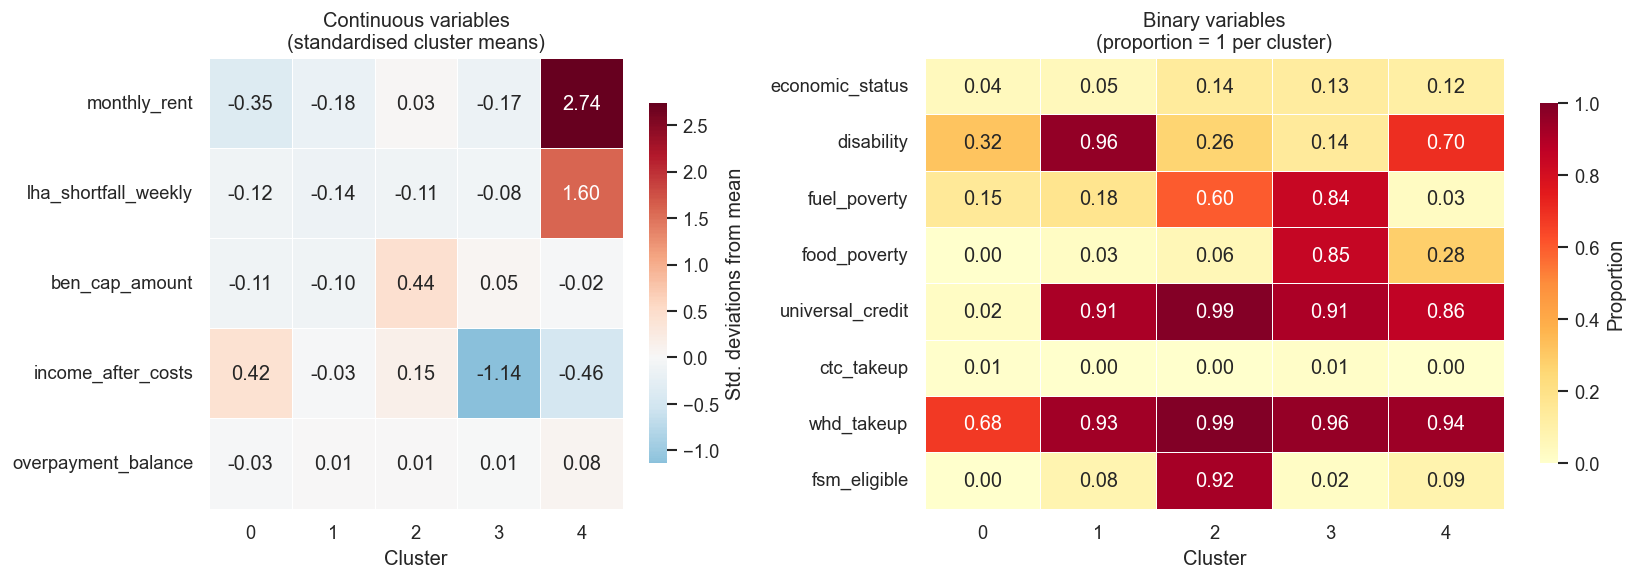

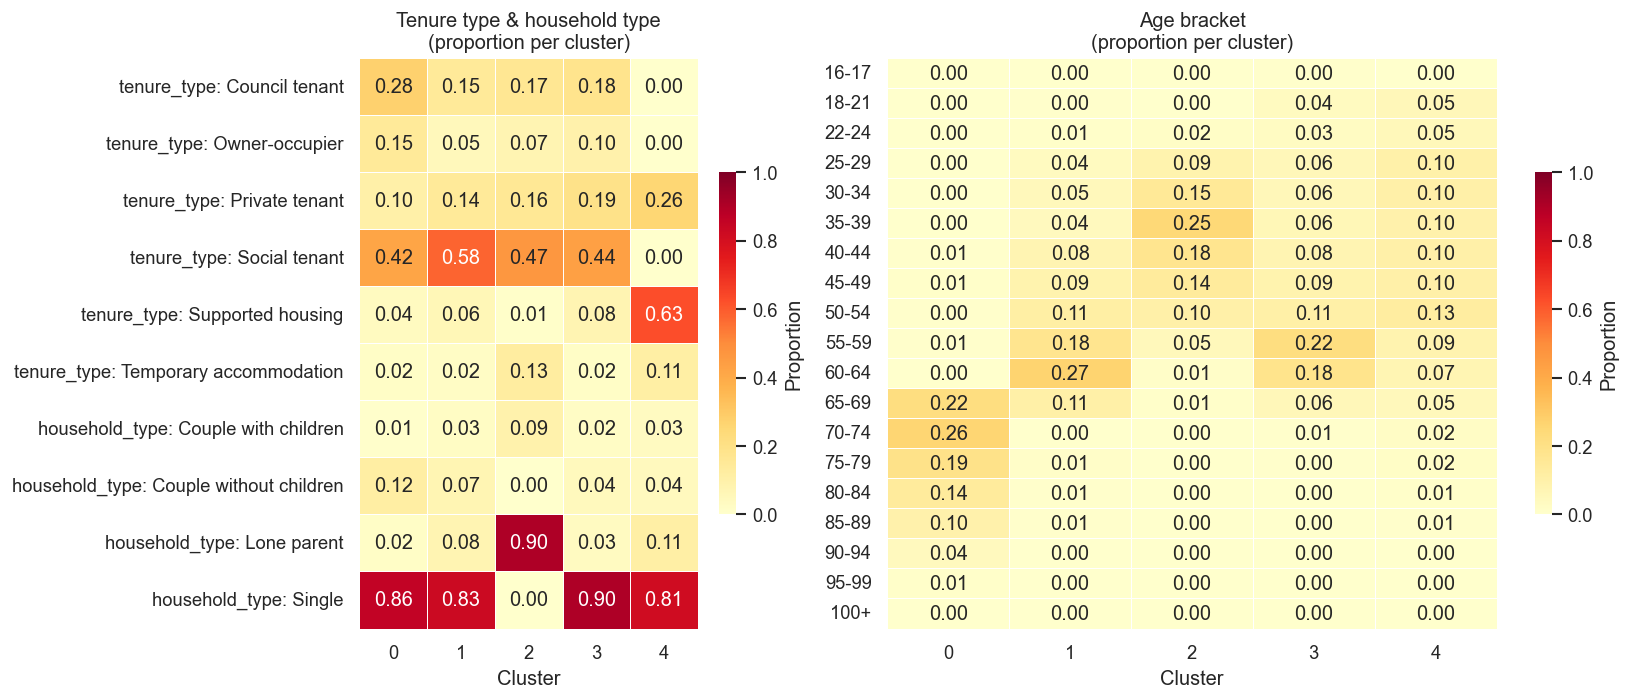

In [715]:
FULL_WIDTH = 14

# --- Heatmap 1: continuous variables (standardised means per cluster) ---
cont_means_df = df.groupby('cluster')[cont_cols].mean()
overall_mean = df[cont_cols].mean()
overall_std  = df[cont_cols].std()
cont_z = (cont_means_df - overall_mean) / overall_std

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 5),
                         gridspec_kw={'width_ratios': [1, 1.4]})

sns.heatmap(cont_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Std. deviations from mean'},
            ax=axes[0])
axes[0].set_title('Continuous variables\n(standardised cluster means)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('')

# --- Heatmap 2: binary variables (proportions per cluster) ---
bin_cols_heatmap = ['economic_status', 'disability', 'fuel_poverty', 'food_poverty',
                    'universal_credit', 'ctc_takeup', 'whd_takeup', 'fsm_eligible']
bin_props = df.groupby('cluster')[bin_cols_heatmap].mean()

sns.heatmap(bin_props.T, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Proportion'},
            ax=axes[1])
axes[1].set_title('Binary variables\n(proportion = 1 per cluster)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '4_2_heatmap_continuous_binary.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Heatmap 3 & 4: nominal categoricals (tenure, household type) and age bracket ---
nominal_cats_no_age = ['tenure_type', 'household_type']

nominal_rows = {}
for col in nominal_cats_no_age:
    ct = pd.crosstab(df['cluster'], df[col], normalize='index')
    for level in ct.columns:
        nominal_rows[f'{col}: {level}'] = ct[level]

nominal_props = pd.DataFrame(nominal_rows).T
nominal_props = nominal_props.loc[sorted(nominal_props.index,
    key=lambda x: (nominal_cats_no_age.index(x.split(':')[0].strip()), x))]

# Age bracket separately
age_ct = pd.crosstab(df['cluster'], df['age_bracket'], normalize='index')
age_order = sorted(age_ct.columns, key=lambda x: int(x.replace('+', '').split('-')[0]))
age_ct = age_ct[age_order]

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 6),
                         gridspec_kw={'width_ratios': [1, 1.8]})

sns.heatmap(nominal_props, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.6, 'label': 'Proportion'},
            ax=axes[0])
axes[0].set_title('Tenure type & household type\n(proportion per cluster)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('')

sns.heatmap(age_ct.T, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.6, 'label': 'Proportion'},
            ax=axes[1])
axes[1].set_title('Age bracket\n(proportion per cluster)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '4_2_heatmap_nominal_age.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Key takeaways

Five distinct vulnerability profiles emerge, ordered by cluster size. The table below synthesises what the summary table and heatmaps show for each cluster:

<table>
<thead>
<tr><th>Cluster</th><th>Size</th><th>Arrears rate</th><th>Summary table profile</th><th>Heatmap signature</th></tr>
</thead>
<tbody>
<tr><td>0</td><td>34.8%</td><td>10.1%</td>
<td>
• Social tenant, single<br>
• Oldest group (age 70–74 mode)<br>
• Only 2% on UC (legacy benefits)<br>
• Lower WHD takeup than other clusters<br>
• Highest income after costs (£1,029)<br>
• Lowest arrears rate (10.1%), lowest mean arrears (£168)
</td>
<td>
• WHD takeup<br>
• Social tenant, single<br>
• Age 70–74
</td></tr>
<tr><td>1</td><td>31.6%</td><td>34.7%</td>
<td>
• Social tenant, single<br>
• Older (age 60–64 mode)<br>
• 96% disabled<br>
• UC and WHD takeup<br>
• 34.7% arrears rate, mean arrears £587
</td>
<td>
• WHD takeup, UC<br>
• Disability<br>
• Social tenant, single<br>
• Age 60–64
</td></tr>
<tr><td>2</td><td>15.2%</td><td>38.1%</td>
<td>
• Social tenant, lone parent<br>
• Mid-thirties (age 35–39 mode)<br>
• 92% FSM eligible (but only 6% food poverty — an interesting tension)<br>
• UC, WHD takeup, 60% fuel poverty<br>
• Slightly higher employment rate (14%)<br>
• 38.1% arrears rate, mean arrears £654
</td>
<td>
• FSM, WHD takeup, UC<br>
• Fuel poverty<br>
• Social tenant, lone parent<br>
• Age 35–39
</td></tr>
<tr><td>3</td><td>11.3%</td><td>40.6%</td>
<td>
• Social tenant, single<br>
• Older (age 55–59 mode)<br>
• UC, WHD takeup<br>
• 84% fuel poverty, 85% food poverty<br>
• Mean income after costs is negative (−£78)<br>
• Highest arrears rate (40.6%), mean arrears £803
</td>
<td>
• WHD takeup, UC<br>
• Food poverty, fuel poverty<br>
• Social tenant, single<br>
• Age 55–59
</td></tr>
<tr><td>4</td><td>7.1%</td><td>9.0%</td>
<td>
• Supported housing, single<br>
• Age 50–54 mode<br>
• 70% disabled<br>
• UC, WHD takeup<br>
• 2nd highest food poverty (28%)<br>
• Highest overpayment balance (£269)<br>
• Highest monthly rent (£2,916)<br>
• 2nd lowest income after costs (£405)<br>
• 2nd lowest arrears rate (9.0%), lowest mean arrears £82
</td>
<td>
• WHD takeup, UC<br>
• Disability<br>
• Supported housing, single<br>
• Age 50–54
</td></tr>
</tbody>
</table>

All five clusters are predominantly social tenants and single-person households — the two exceptions are cluster 4 (majority supported housing) and cluster 2 (majority lone parents). The clusters split into two broad groups:

**Relatively better off (low arrears, 9–10%):**
- **Cluster 0:**
  - Old (70–74)
  - Not on Universal Credit
  - Highest income after costs
  - WHD takeup noticeably lower than other clusters, consistent with being on legacy benefits rather than the UC-linked system
- **Cluster 4:**
  - Older (50–54)
  - Disabled
  - Universal Credit
  - High monthly rent and overpayment balance
  - Relatively low income after costs
  - The supported housing structure may be protective here (e.g. rent paid directly to the provider), which would explain low arrears despite financial stress on multiple dimensions

**Relatively worse off (high arrears, 35–41%):**
- **Cluster 1:**
  - Disabled
  - Universal Credit
  - Older (60–64)
- **Cluster 2:**
  - Lone parent
  - Universal Credit
  - Free school meals eligibility
  - Fuel poverty
  - Notably, only 6% food poverty despite 92% FSM eligibility and 60% fuel poverty — this could reflect how food poverty is measured, or that child-related benefits are sufficient for food but not energy costs
- **Cluster 3:**
  - Older (55–59)
  - Universal Credit
  - Fuel poverty, food poverty
  - Negative income after costs

Clusters 2 and 3 in particular are characterised by multiple co-occurring stressors beyond Universal Credit: cluster 2 by being lone parents with fuel poverty and free school meals eligibility, and cluster 3 by fuel and food poverty and negative income after costs. Yet clusters with similar arrears rates can have completely different profiles — cluster 1 (older disabled singles) and cluster 2 (younger lone parents) both sit around 35–38%, but the intervention logic for each would differ substantially.

**Further observations:**
- **WHD takeup is high across all clusters** (85.5% overall) and does not differentiate them, except for cluster 0 where it is noticeably lower — consistent with that cluster being on legacy benefits rather than the UC-linked system.
- **No single characteristic is associated with high arrears in isolation.** Cluster 1 is 96% disabled with moderate arrears; cluster 3 is 15% disabled with the highest arrears. What differs is the constellation of co-occurring factors — poverty indicators, income, benefit status — not any one variable.

### Choosing k: comparison of k=3, 4, 5

To justify the choice of k=5, we run k=3 and k=4 with the same settings and compare the profiles that emerge.

In [716]:
# --- Run k=3 and k=4 for comparison ---
for k in [3, 4]:
    kp_alt = KPrototypes(n_clusters=k, init='Cao', gamma=3.0, random_state=42, n_jobs=-1)
    raw_alt = kp_alt.fit_predict(X, categorical=cat_indices)

    # Relabel by size
    sizes_alt = pd.Series(raw_alt).value_counts().sort_values(ascending=False)
    lmap = {old: new for new, old in enumerate(sizes_alt.index)}
    df[f'cluster_k{k}'] = pd.Series(raw_alt).map(lmap).values

    print(f'\n=== k={k} ===')
    for c in range(k):
        sub = df[df[f'cluster_k{k}'] == c]
        tenure_mode = sub['tenure_type'].mode()[0]
        hh_mode = sub['household_type'].mode()[0]
        age_mode = sub['age_bracket'].mode()[0]
        print(f'  Cluster {c} ({len(sub):,}, {len(sub)/len(df)*100:.1f}%): '
              f'{tenure_mode}, {hh_mode}, age {age_mode}, '
              f'disabled {sub["disability"].mean()*100:.0f}%, '
              f'UC {sub["universal_credit"].mean()*100:.0f}%, '
              f'fuel pov {sub["fuel_poverty"].mean()*100:.0f}%, '
              f'food pov {sub["food_poverty"].mean()*100:.0f}%, '
              f'FSM {sub["fsm_eligible"].mean()*100:.0f}%, '
              f'income £{sub["income_after_costs"].mean():,.0f}, '
              f'arrears {sub["arrears_flag"].mean()*100:.1f}%')

    # Clean up temporary column
    df.drop(columns=[f'cluster_k{k}'], inplace=True)


=== k=3 ===
  Cluster 0 (7,713, 43.3%): Social tenant, Single, age 60-64, disabled 78%, UC 96%, fuel pov 29%, food pov 23%, FSM 4%, income £471, arrears 33.3%
  Cluster 1 (6,949, 39.0%): Social tenant, Single, age 65-69, disabled 34%, UC 5%, fuel pov 18%, food pov 3%, FSM 0%, income £991, arrears 11.0%
  Cluster 2 (3,169, 17.8%): Social tenant, Lone parent, age 35-39, disabled 30%, UC 99%, fuel pov 58%, food pov 11%, FSM 88%, income £796, arrears 38.4%

=== k=4 ===
  Cluster 0 (6,406, 35.9%): Social tenant, Single, age 70-74, disabled 33%, UC 2%, fuel pov 15%, food pov 0%, FSM 0%, income £1,016, arrears 10.4%
  Cluster 1 (6,399, 35.9%): Social tenant, Single, age 60-64, disabled 94%, UC 93%, fuel pov 15%, food pov 4%, FSM 7%, income £692, arrears 30.7%
  Cluster 2 (2,803, 15.7%): Social tenant, Lone parent, age 35-39, disabled 28%, UC 99%, fuel pov 59%, food pov 6%, FSM 93%, income £847, arrears 38.6%
  Cluster 3 (2,223, 12.5%): Social tenant, Single, age 55-59, disabled 15%, UC 91%, 

**What changes across k:**

- **Stable across all k values**: the lone parents cluster and the older legacy benefits cluster appear at k=3 and persist essentially unchanged through k=4 and k=5.
- **k=3 → k=4**: the large UC singles cluster (k=3 cluster 0: disabled 78%, fuel poverty 29%, food poverty 23%, arrears 33%) splits into two groups — one dominated by disability (94%, arrears 31%) and one by deep financial hardship (fuel poverty 77%, food poverty 87%, negative income, arrears 38%). This is a meaningful distinction: the disability group has moderate arrears, while the deep hardship group has substantially higher arrears and a qualitatively different profile.
- **k=4 → k=5**: the disabled singles cluster further separates out a supported housing subgroup (7%) with very high rent, high disability, but very low arrears. This is a smaller but policy-relevant distinction — these households look financially stressed but are structurally protected from arrears.

**Why k=5**: k=3 is too coarse — it merges groups with meaningfully different profiles and arrears rates into one large cluster. k=4 captures the main structure but misses the supported housing group, which is a small but distinct population with different dynamics. k=5 surfaces all five profiles without producing clusters that are too small or uninterpretable.

### Cluster stability across random seeds

The k=5 solution above uses a single random seed (`random_state=42`). Because k-prototypes initialisation is stochastic, it's worth checking whether the five profiles we identified are a genuine feature of the data or an artefact of one particular seed. We re-run k=5 with four different seeds and compare the cluster summaries.

In [717]:
# --- Run k=5 with different random seeds ---
seeds = [0, 7, 42, 123]
for seed in seeds:
    kp_s = KPrototypes(n_clusters=5, init='Cao', gamma=3.0, random_state=seed, n_jobs=-1)
    raw_s = kp_s.fit_predict(X, categorical=cat_indices)

    # Relabel by size
    sizes_s = pd.Series(raw_s).value_counts().sort_values(ascending=False)
    lmap = {old: new for new, old in enumerate(sizes_s.index)}
    df['cluster_seed'] = pd.Series(raw_s).map(lmap).values

    print(f'\n=== seed={seed} ===')
    for c in range(5):
        sub = df[df['cluster_seed'] == c]
        tenure_mode = sub['tenure_type'].mode()[0]
        hh_mode = sub['household_type'].mode()[0]
        age_mode = sub['age_bracket'].mode()[0]
        print(f'  Cluster {c} ({len(sub):,}, {len(sub)/len(df)*100:.1f}%): '
              f'{tenure_mode}, {hh_mode}, age {age_mode}, '
              f'disabled {sub["disability"].mean()*100:.0f}%, '
              f'UC {sub["universal_credit"].mean()*100:.0f}%, '
              f'fuel pov {sub["fuel_poverty"].mean()*100:.0f}%, '
              f'food pov {sub["food_poverty"].mean()*100:.0f}%, '
              f'FSM {sub["fsm_eligible"].mean()*100:.0f}%, '
              f'income £{sub["income_after_costs"].mean():,.0f}, '
              f'arrears {sub["arrears_flag"].mean()*100:.1f}%')

df.drop(columns=['cluster_seed'], inplace=True)


=== seed=0 ===
  Cluster 0 (6,748, 37.8%): Social tenant, Single, age 60-64, disabled 81%, UC 93%, fuel pov 31%, food pov 19%, FSM 5%, income £563, arrears 35.8%
  Cluster 1 (3,959, 22.2%): Council tenant, Single, age 75-79, disabled 24%, UC 8%, fuel pov 24%, food pov 7%, FSM 0%, income £828, arrears 13.0%
  Cluster 2 (3,016, 16.9%): Social tenant, Lone parent, age 35-39, disabled 28%, UC 99%, fuel pov 59%, food pov 10%, FSM 88%, income £804, arrears 37.5%
  Cluster 3 (2,738, 15.4%): Social tenant, Single, age 65-69, disabled 41%, UC 4%, fuel pov 14%, food pov 2%, FSM 0%, income £1,130, arrears 13.0%
  Cluster 4 (1,370, 7.7%): Supported housing, Single, age 40-44, disabled 65%, UC 88%, fuel pov 6%, food pov 34%, FSM 9%, income £325, arrears 9.4%

=== seed=7 ===
  Cluster 0 (6,217, 34.9%): Social tenant, Single, age 70-74, disabled 32%, UC 2%, fuel pov 15%, food pov 0%, FSM 0%, income £1,029, arrears 10.1%
  Cluster 1 (5,640, 31.6%): Social tenant, Single, age 60-64, disabled 96%, UC 9

**What is stable across seeds:**

- **Three of the five profiles are robust**: the disabled UC singles cluster, the lone parents cluster, and the older non-UC cluster appear in all four runs with very similar sizes and summary statistics. These are genuine features of the data.
- **The fuel/food poverty cluster appears in 3 of 4 runs**. In the run where it doesn't appear as a distinct cluster, it gets merged into a neighbouring group rather than disappearing — the deep-hardship signal is still present in the data, just absorbed elsewhere.
- **The smallest cluster (high-rent / supported housing or private tenant subgroup) is the most seed-sensitive**: its composition and boundary shift most across runs. This is expected — small clusters sit closer to the edges of the partition and are more easily reshuffled by different initialisations.

**Interpretation**: the overall structure of the k=5 solution is stable. The three largest, most interpretable groups are reproducible, and the deep-hardship signal is consistently detected. Boundaries between smaller, adjacent groups are seed-sensitive, which is a normal property of clustering on mixed-type data with overlapping profiles — not a reason to distrust the main findings. For downstream use (targeting, profiling), it's the robust profiles that matter.

---
## 5. Predictive Models

### What we are predicting

**Classification**: predict `arrears_flag` (binary) — who is at risk of arrears? The model outputs a probability (0–1) for each household, which serves as a continuous risk score suitable for ranking.

### Model choice

Two models from two different families:

- **Logistic regression** (classification): a linear model — it assumes the relationship between each feature and the probability of arrears is linear (on a transformed scale). 
- **Gradient boosting / XGBoost** (classification): an ensemble of sequential decision trees, where each tree corrects the errors of the previous one. Learns non-linear relationships and feature interactions automatically without needing them to be specified.

**Why this combination**: good to see what a simple linear model finds and what a more flexible model adds. If they perform similarly, the relationship is largely linear; if gradient boosting substantially outperforms, there are non-linear effects or interactions the linear model misses.

**Note on severity**: the task focuses on identifying who is at risk of arrears, not predicting how much. A regression model predicting `arrears_amount` is not implemented here but could serve several policy questions:
- **Severity-informed prevention**: for households not yet in arrears, predict how severe the arrears would be if they did fall — and prioritise those who would fall hardest. This is still prevention, but weighted by potential impact.
- **Escalation prevention**: among households already in arrears, predict who is at risk of it getting worse.
- Note that making support *proportional to current arrears amount* would be problematic — arrears are a symptom, not a need. But predicting *potential* severity for at-risk households is a different matter, and could inform how resources are allocated.

These are genuine policy design choices. Severity modelling is deferred to future work.

### Evaluation strategy

**Train/test split.** Before any modelling, the data is split into a training set (80%) and a held-out test set (20%). The test set is set aside completely and used only once at the end, to give an unbiased estimate of how the model would perform on new, unseen households.

**Cross-validation on the training set.** Within the training set, we use **stratified 5-fold cross-validation**. The training data is divided into 5 equal folds; the model is trained on 4 folds and evaluated on the 5th, and this is repeated 5 times so each fold serves as the validation set once. Each household ends up with a prediction from a model that was not trained on it. The 5 fold-level scores are averaged into a single CV score, which gives a more stable estimate of model performance than a single train/validation split.

**Why both?** Cross-validation gives a robust performance estimate during model development without burning the test set. The held-out test set provides a final, untouched check that the model generalises beyond the data used for any tuning or selection.

**Stratified** means each fold preserves the proportion of arrears-positive households (25.5%) — important given the class imbalance, so no fold ends up with too few positives to evaluate meaningfully.

**Model output**: the model assigns each household a probability between 0 and 1. Higher = the model thinks this household is more likely to be in arrears. To actually make decisions ("support this household, don't support that one"), you draw a line somewhere on the 0–1 scale — everyone above gets flagged, everyone below doesn't. This line is the **threshold** (e.g. threshold = 0.5 means: flag anyone scored above 0.5). The choice of threshold is a decision based on resources and priorities, not built into the model.

**Why not plain accuracy?** With 74.5% of households not in arrears, a model that predicts "no arrears" for every single household achieves 74.5% accuracy without learning anything. Accuracy is dominated by the majority class and would not tell us whether the model can actually identify at-risk households. The metrics below focus on how well the model distinguishes arrears from non-arrears households.

**Classification metrics:**

- **AUC-ROC (Area Under the Receiver Operating Characteristic curve)** (0–1): pick one household that is in arrears and one that isn't. The model has scored each. Did the arrears household get a higher score? (Higher, because higher = "more likely in arrears.") AUC-ROC is the proportion of all such pairs where the answer is yes. 0.5 = coin flip, 1.0 = perfect. This measures the model's ability to sort households correctly, without committing to any specific threshold.

- **Precision and recall** (both depend on which threshold you pick):
  - *Precision*: of the households the model flags, what proportion are actually in arrears? High precision = few false alarms.
  - *Recall*: of all households actually in arrears, what proportion did the model catch? High recall = few missed cases.
  - You can't maximise both. Lowering the threshold flags more households — you catch more true cases (recall up) but also more false alarms (precision down). Raising it does the reverse.
  - Which to prioritise depends on the cost of each type of error: false alarms (flagging non-arrears households) vs missed cases (failing to flag arrears households).

- **PR-AUC (Area Under the Precision-Recall curve)**: for every possible threshold, compute precision and recall — this traces a curve. PR-AUC is the area under that curve (a high value means that high precision and high recall are achieved simultaneously across different threshold settings). A higher curve (top-right corner) means a better trade-off is available: you can catch more true cases without as many false alarms. A random baseline achieves PR-AUC ≈ 0.255 (the prevalence rate), so values above that indicate the model is learning something. In the plots below, the curve is coloured by threshold so you can see where each threshold lands.

- **F1 score**: combines precision and recall at one specific threshold (here: 0.5) into a single number. It penalises imbalance — if precision is 90% but recall is 10%, F1 is low (0.18), not the 50% a simple average would give. For our task (rank households, take the top 10%), the ranking metrics (AUC-ROC, PR-AUC) matter more than performance at a fixed threshold.

### 5.1 Feature preparation

**Both models (logistic regression and gradient boosting) use the same set of features.** The only difference is how categorical variables are encoded (see below). The full feature list:

| Feature | Type | Notes |
|---|---|---|
| `monthly_rent` | Continuous | |
| `lha_shortfall_weekly` | Continuous | |
| `ben_cap_amount` | Continuous | 1 missing value imputed with median |
| `income_after_costs` | Continuous | |
| `overpayment_balance` | Continuous | |
| `imd_rank` | Continuous | Area-level, 175 distinct values |
| `imd_decile` | Ordinal | Area-level, values 1–10 |
| `economic_status` | Binary (0/1) | |
| `disability` | Binary (0/1) | |
| `fuel_poverty` | Binary (0/1) | |
| `food_poverty` | Binary (0/1) | |
| `universal_credit` | Binary (0/1) | |
| `whd_takeup` | Binary (0/1) | |
| `fsm_eligible` | Binary (0/1) | |
| `tenure_type` | Nominal (6 levels) | One-hot (LR) / ordinal-encoded (tree) |
| `household_type` | Nominal (4 levels) | One-hot (LR) / ordinal-encoded (tree) |
| `age_bracket` | Nominal (19 levels) | One-hot (LR) / ordinal-encoded (tree) |
| `ward` | Nominal (19 levels) | One-hot (LR) / ordinal-encoded (tree) |

**Excluded:**
- `reference` — household identifier, no predictive meaning.
- `ctc_takeup` — near-zero variance (0.4% of households), a legacy benefit being replaced by Universal Credit. Adds noise without signal.
- `arrears_flag` and `arrears_amount` — targets.
- `lsoa21cd` — geographic identifier with 175 unique values. The reasons for excluding it are pragmatic:
  - One-hot encoding 175 LSOAs would produce 174 binary columns for logistic regression — a large expansion relative to the other features.
  - Some LSOAs contain very few households, so the model risks memorising LSOA-level arrears rates rather than learning generalisable patterns (overfitting).

**Note on geography and the correlation analysis:** `ward` is a nominal category with no meaningful ordering, so it could not be included in the Spearman correlation heatmap in Section 3 (which requires ranked variables). The predictive models handle it directly — logistic regression via one-hot encoding, tree models via ordinal encoding — and SHAP analysis (Section 5.5) reveals how important geography turns out to be. This is a genuine limitation of the pairwise correlation approach: a strong predictor can be invisible to it if the variable type is incompatible.

**Pipeline architecture:** Both models are built as sklearn `Pipeline` objects combining a `ColumnTransformer` (which applies the right encoder to each column type) with the classifier. Using pipelines means all preprocessing — encoding, imputation, standardisation — is fit on training folds only during cross-validation, eliminating within-CV leakage that would otherwise occur if encoders or scalers were fit on the full training set before splitting. It also keeps the code compact: no manual column tracking, no separate `X_train`/`X_test` matrices per model.

**Encoding:**
- **Logistic regression — one-hot encoding + standardisation:**
  - Nominal categoricals (`tenure_type`, `household_type`, `age_bracket`, `ward`) are one-hot encoded: each categorical variable is converted into multiple binary (0/1) columns, one per category level (minus one to avoid redundancy). For example, `tenure_type` with 6 levels becomes 5 binary columns. This is necessary because logistic regression treats features as numeric — assigning arbitrary integers (e.g. "social tenant = 3") would imply a false linear ordering.
  - This expands the original ~15 features to 58 (the nominal categoricals alone produce ~44 binary columns: tenure 5, household type 3, age bracket 18, ward 18).
  - Continuous features are standardised (subtract mean, divide by standard deviation) so that features with large numeric ranges (e.g. rent in £) do not dominate those with small ranges (e.g. binary 0/1). Binary and one-hot features are already on a 0/1 scale and are not affected meaningfully by standardisation.
- **Tree-based models — ordinal encoding, no standardisation:**
  - Nominal categoricals are ordinal-encoded: each category is assigned an arbitrary integer. Trees split on thresholds ("is tenure ≤ 3?") and do not treat the integers as linearly ordered, so this is safe.
  - This keeps the feature count at 18 (the original features minus the 4 excluded, plus 2 IMD variables).
  - No standardisation needed — tree-based models are scale-invariant (they split on rank order, not absolute values).

In [718]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc, roc_curve
import xgboost as xgb
import shap

# --- Define targets and features to drop ---
# ctc_takeup excluded: near-zero variance (0.4% positive), legacy benefit replaced by UC — adds noise without signal
drop_cols = ['reference', 'lsoa21cd', 'arrears_flag', 'arrears_amount', 'ctc_takeup']
extra_drop = [c for c in df.columns if c in ['cluster', 'age_bracket_ord', 'income_bin', 'total_shortfall']]
drop_all = drop_cols + extra_drop

cat_nominal = ['tenure_type', 'household_type', 'age_bracket', 'ward']

y_clf = df['arrears_flag'].values

# --- Train/test split (80/20, stratified) ---
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, stratify=y_clf, random_state=42)

y_clf_train = y_clf[train_idx]
y_clf_test = y_clf[test_idx]

print(f'Train: {len(train_idx):,}  |  Test: {len(test_idx):,}')
print(f'Train arrears rate: {y_clf_train.mean()*100:.1f}%  |  Test: {y_clf_test.mean()*100:.1f}%')

# --- Feature dataframes (shared across both models) ---
train_df = df.iloc[train_idx].drop(columns=drop_all).copy()
test_df = df.iloc[test_idx].drop(columns=drop_all).copy()

# --- Logistic regression: ColumnTransformer + Pipeline ---
# Nominal categoricals get one-hot encoded; everything else (continuous + binary)
# goes through StandardScaler via `remainder`. Wrapping this in a Pipeline with the
# classifier means the scaler and encoder are refit inside each CV fold automatically
# — no within-CV leakage from preprocessing fitted on the whole training set.
lr_preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_nominal),
    ],
    remainder=StandardScaler(),
)
lr_pipe = Pipeline([
    ('prep', lr_preprocess),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
])

# --- XGBoost: ColumnTransformer + Pipeline ---
# Nominal categoricals get ordinal-encoded (trees split on integer thresholds, so arbitrary
# integer codes are fine — no false ordering is imposed). Everything else passes through
# untouched (trees are scale-invariant). handle_unknown='use_encoded_value' / unknown_value=-1
# means any category that appears in a validation fold but not in the corresponding training
# subfold is safely encoded as -1 instead of crashing the CV.
scale_pos = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()

xgb_preprocess = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_nominal),
    ],
    remainder='passthrough',
)
xgb_pipe = Pipeline([
    ('prep', xgb_preprocess),
    ('clf', xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_pos,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1,
    )),
])

Train: 14,264  |  Test: 3,567
Train arrears rate: 25.5%  |  Test: 25.5%


### 5.2 Logistic regression (classification)

In [719]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV predictions on training set — preprocessing refits per fold automatically
lr_cv_probs = cross_val_predict(
    lr_pipe, train_df, y_clf_train, cv=cv, method='predict_proba')[:, 1]

# Fit on full training set, predict on test
lr_pipe.fit(train_df, y_clf_train)
lr_test_probs = lr_pipe.predict_proba(test_df)[:, 1]
lr_test_preds = (lr_test_probs >= 0.5).astype(int)

# Metrics
lr_cv_auc = roc_auc_score(y_clf_train, lr_cv_probs)
lr_test_auc = roc_auc_score(y_clf_test, lr_test_probs)
lr_test_f1 = f1_score(y_clf_test, lr_test_preds)
prec, rec, _ = precision_recall_curve(y_clf_test, lr_test_probs)
lr_test_pr_auc = auc(rec, prec)

# Feature count after one-hot encoding (available once the pipeline has been fitted)
n_lr_features = lr_pipe.named_steps['prep'].get_feature_names_out().shape[0]

print(f'Logistic regression ({n_lr_features} features after one-hot)')
print(f'  CV AUC-ROC:   {lr_cv_auc:.3f}')
print(f'  Test AUC-ROC: {lr_test_auc:.3f}')
print(f'  Test PR-AUC:  {lr_test_pr_auc:.3f}')
print(f'  Test F1:      {lr_test_f1:.3f}')

Logistic regression (58 features after one-hot)
  CV AUC-ROC:   0.771
  Test AUC-ROC: 0.776
  Test PR-AUC:  0.516
  Test F1:      0.555


### 5.3 Gradient boosting — classification (XGBoost)

In [720]:
# CV predictions on training set — preprocessing refits per fold automatically
xgb_cv_probs = cross_val_predict(
    xgb_pipe, train_df, y_clf_train, cv=cv, method='predict_proba')[:, 1]

# Fit on full training set, predict on test
xgb_pipe.fit(train_df, y_clf_train)
xgb_test_probs = xgb_pipe.predict_proba(test_df)[:, 1]
xgb_test_preds = (xgb_test_probs >= 0.5).astype(int)

# Metrics
xgb_cv_auc = roc_auc_score(y_clf_train, xgb_cv_probs)
xgb_test_auc = roc_auc_score(y_clf_test, xgb_test_probs)
xgb_test_f1 = f1_score(y_clf_test, xgb_test_preds)
prec, rec, _ = precision_recall_curve(y_clf_test, xgb_test_probs)
xgb_test_pr_auc = auc(rec, prec)

print(f'XGBoost classifier')
print(f'  CV AUC-ROC:   {xgb_cv_auc:.3f}')
print(f'  Test AUC-ROC: {xgb_test_auc:.3f}')
print(f'  Test PR-AUC:  {xgb_test_pr_auc:.3f}')
print(f'  Test F1:      {xgb_test_f1:.3f}')

XGBoost classifier
  CV AUC-ROC:   0.769
  Test AUC-ROC: 0.779
  Test PR-AUC:  0.523
  Test F1:      0.545


### 5.4 Model comparison

ROC and precision-recall curves show **XGBoost** coloured by threshold (viridis), with **logistic regression** in grey for reference. The comparison table follows.

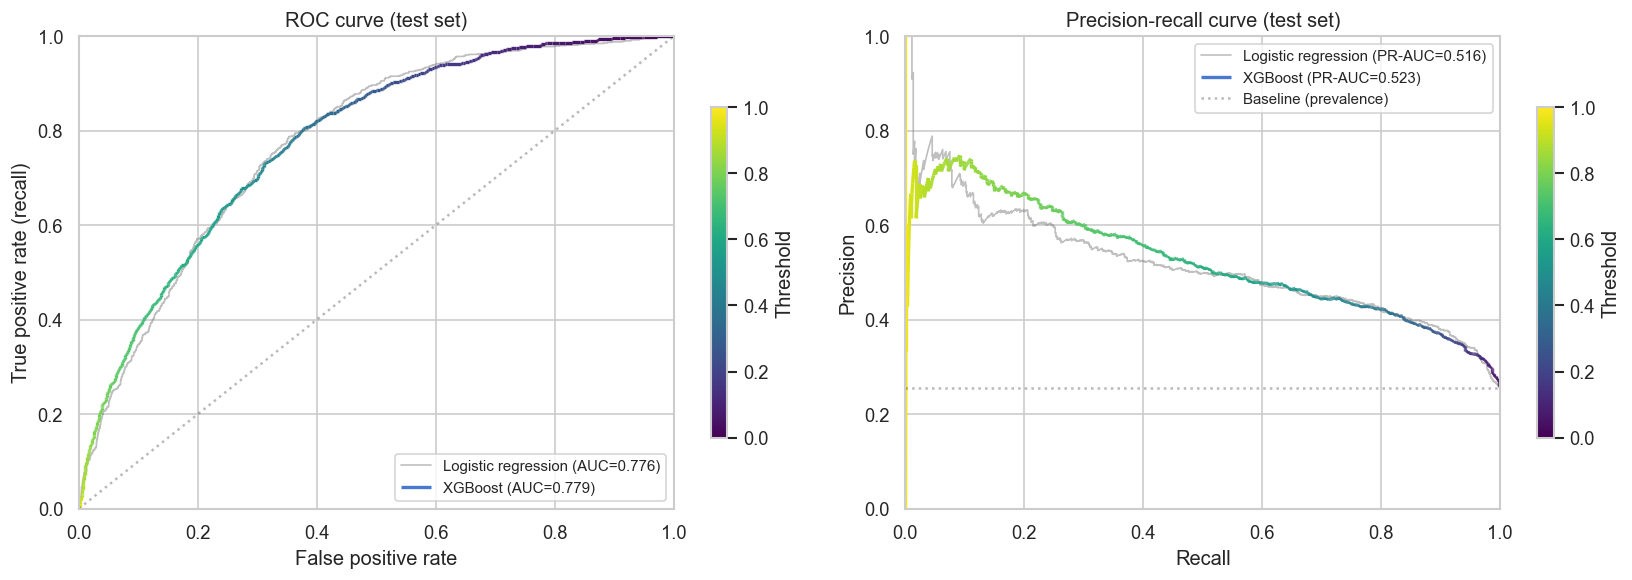

Classification models:


,CV AUC-ROC,Test AUC-ROC,Test PR-AUC,Test F1
Model,,,,
Logistic regression,0.771,0.776,0.516,0.555
XGBoost,0.769,0.779,0.523,0.545


In [721]:
FULL_WIDTH = 14
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# --- Helper: plot a curve coloured by threshold ---
def plot_coloured_curve(ax, x, y, thresholds, cmap_name, label, norm):
    """Plot a line coloured by threshold values."""
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap_name, norm=norm, linewidth=2, label=label)
    lc.set_array(thresholds[:-1])
    ax.add_collection(lc)
    ax.autoscale()

# Curves show XGBoost (coloured by threshold) with logistic regression in grey for reference.
norm = Normalize(vmin=0, vmax=1)

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 5))

# --- ROC curve ---
# LR reference
fpr_lr, tpr_lr, _ = roc_curve(y_clf_test, lr_test_probs)
axes[0].plot(fpr_lr, tpr_lr, color='grey', linewidth=1, alpha=0.5,
             label=f'Logistic regression (AUC={lr_test_auc:.3f})')

# XGBoost coloured by threshold
fpr_xgb, tpr_xgb, thresholds_roc = roc_curve(y_clf_test, xgb_test_probs)
plot_coloured_curve(axes[0], fpr_xgb, tpr_xgb, thresholds_roc, 'viridis',
                    f'XGBoost (AUC={xgb_test_auc:.3f})', norm)

axes[0].plot([0, 1], [0, 1], 'k:', alpha=0.3)
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate (recall)')
axes[0].set_title('ROC curve (test set)')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].legend(fontsize=9, loc='lower right')

# Colourbar
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, ax=axes[0], shrink=0.7)
cb.set_label('Threshold')

# --- Precision-recall curve ---
# LR reference
prec_lr, rec_lr, _ = precision_recall_curve(y_clf_test, lr_test_probs)
axes[1].plot(rec_lr, prec_lr, color='grey', linewidth=1, alpha=0.5,
             label=f'Logistic regression (PR-AUC={lr_test_pr_auc:.3f})')

# XGBoost coloured by threshold
prec_xgb, rec_xgb, thresholds_pr = precision_recall_curve(y_clf_test, xgb_test_probs)
# precision_recall_curve returns thresholds with len = len(prec) - 1, append 1.0
thresholds_pr_full = np.append(thresholds_pr, 1.0)
plot_coloured_curve(axes[1], rec_xgb, prec_xgb, thresholds_pr_full, 'viridis',
                    f'XGBoost (PR-AUC={xgb_test_pr_auc:.3f})', norm)

axes[1].axhline(y_clf_test.mean(), color='k', linestyle=':', alpha=0.3,
                label='Baseline (prevalence)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-recall curve (test set)')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].legend(fontsize=9, loc='upper right')

# Colourbar
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, ax=axes[1], shrink=0.7)
cb.set_label('Threshold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '5_4_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Classification comparison table ---
comp = pd.DataFrame({
    'Model': ['Logistic regression', 'XGBoost'],
    'CV AUC-ROC': [lr_cv_auc, xgb_cv_auc],
    'Test AUC-ROC': [lr_test_auc, xgb_test_auc],
    'Test PR-AUC': [lr_test_pr_auc, xgb_test_pr_auc],
    'Test F1': [lr_test_f1, xgb_test_f1],
}).set_index('Model')

print('Classification models:')
display(comp.round(3))


### 5.5 Feature importance — SHAP values

**SHAP (SHapley Additive exPlanations)** quantifies how much each feature contributed to each household's predicted score — in which direction and by how much.

**The intuition.** SHAP comes from cooperative game theory (Shapley values). The idea is: take all possible subsets of features, and for each subset, ask *how much does adding feature X change the prediction?* Then average that change across all subsets. So SHAP measures the average marginal contribution of a feature across all possible combinations of other features. This accounts for the fact that a feature's impact depends on which other features are present.

**What the plots show.** Averaging the absolute SHAP values across all households gives overall feature importance (the bar plot). The beeswarm plot shows both importance and direction: each dot is one household, colour indicates feature value (red = high, blue = low), and horizontal position shows how much that feature pushed the prediction up or down.

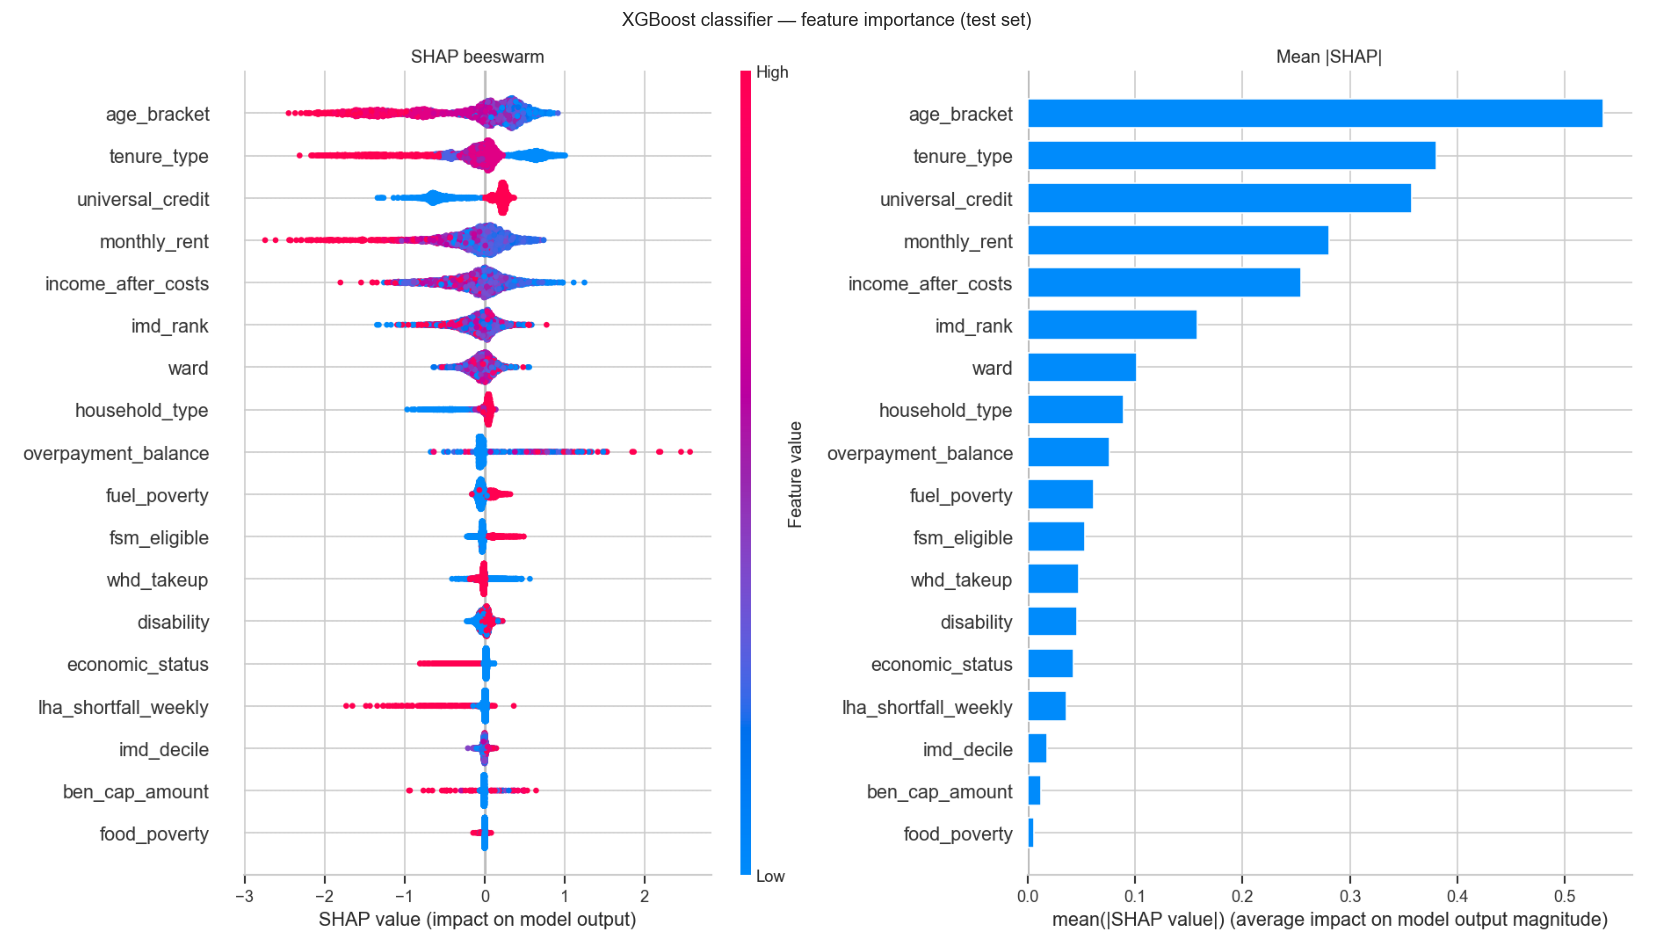

In [722]:
# --- SHAP for XGBoost classifier (fitted on full training set, via pipeline) ---
from io import BytesIO
from PIL import Image

# Extract the fitted classifier and the fitted preprocessor from the pipeline.
# TreeExplainer needs the raw XGBoost booster, and we must hand it features that have
# already been passed through the same preprocessing the classifier was trained on.
xgb_fitted = xgb_pipe.named_steps['clf']
xgb_prep = xgb_pipe.named_steps['prep']

X_test_transformed = xgb_prep.transform(test_df)

# ColumnTransformer prefixes its output columns with the transformer name ('cat__', 'remainder__').
# Strip those prefixes so the SHAP plots show the original feature names.
feature_names_xgb = [n.split('__', 1)[-1] for n in xgb_prep.get_feature_names_out()]

explainer = shap.TreeExplainer(xgb_fitted)
shap_values = explainer.shap_values(X_test_transformed)

# Render each SHAP plot to an image buffer
buffers = []
for plot_type, title in [('dot', 'SHAP beeswarm'), ('bar', 'Mean |SHAP|')]:
    plt.figure(figsize=(FULL_WIDTH / 2, 6))
    shap.summary_plot(shap_values, X_test_transformed,
                      feature_names=feature_names_xgb,
                      plot_type=plot_type, show=False, max_display=20)
    plt.title(title)
    plt.tight_layout()
    buf = BytesIO()
    plt.gcf().savefig(buf, format='png', dpi=120, bbox_inches='tight')
    plt.close('all')
    buf.seek(0)
    buffers.append(Image.open(buf))

# Composite side by side
widths = [img.width for img in buffers]
heights = [img.height for img in buffers]
total_w = sum(widths)
max_h = max(heights)

composite = Image.new('RGB', (total_w, max_h), 'white')
composite.paste(buffers[0], (0, 0))
composite.paste(buffers[1], (widths[0], 0))

# Display at FULL_WIDTH, height scaled to match aspect ratio
aspect = max_h / total_w
fig, ax = plt.subplots(figsize=(FULL_WIDTH, FULL_WIDTH * aspect))
ax.imshow(composite)
ax.axis('off')
fig.suptitle('XGBoost classifier — feature importance (test set)', fontsize=11, y=1.0)
fig.subplots_adjust(left=0, right=1, top=0.97, bottom=0)
plt.savefig(PLOTS_DIR / '5_5_shap_composite.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Geographic aggregation — LSOA-level predicted risk

The classification model produces a predicted probability for each household. To create a small-area risk picture, these household-level probabilities are averaged within each LSOA: if an LSOA contains 100 households with a mean predicted probability of 0.35, that LSOA's predicted risk is 35%. This is compared side-by-side with the actual arrears rate per LSOA.

**Predictions are out-of-sample for every household.** For each household, we use the prediction made by a model that did *not* see it during training:
- For households in the **training set**, we use their cross-validated prediction — during 5-fold CV, each training household was held out from one fold and predicted by the model trained on the other four folds.
- For households in the **held-out test set**, we use the prediction from the model fitted on the full training set (which never saw the test set).

This avoids the inflated apparent performance you would get by predicting on training data with a model that learned from it.

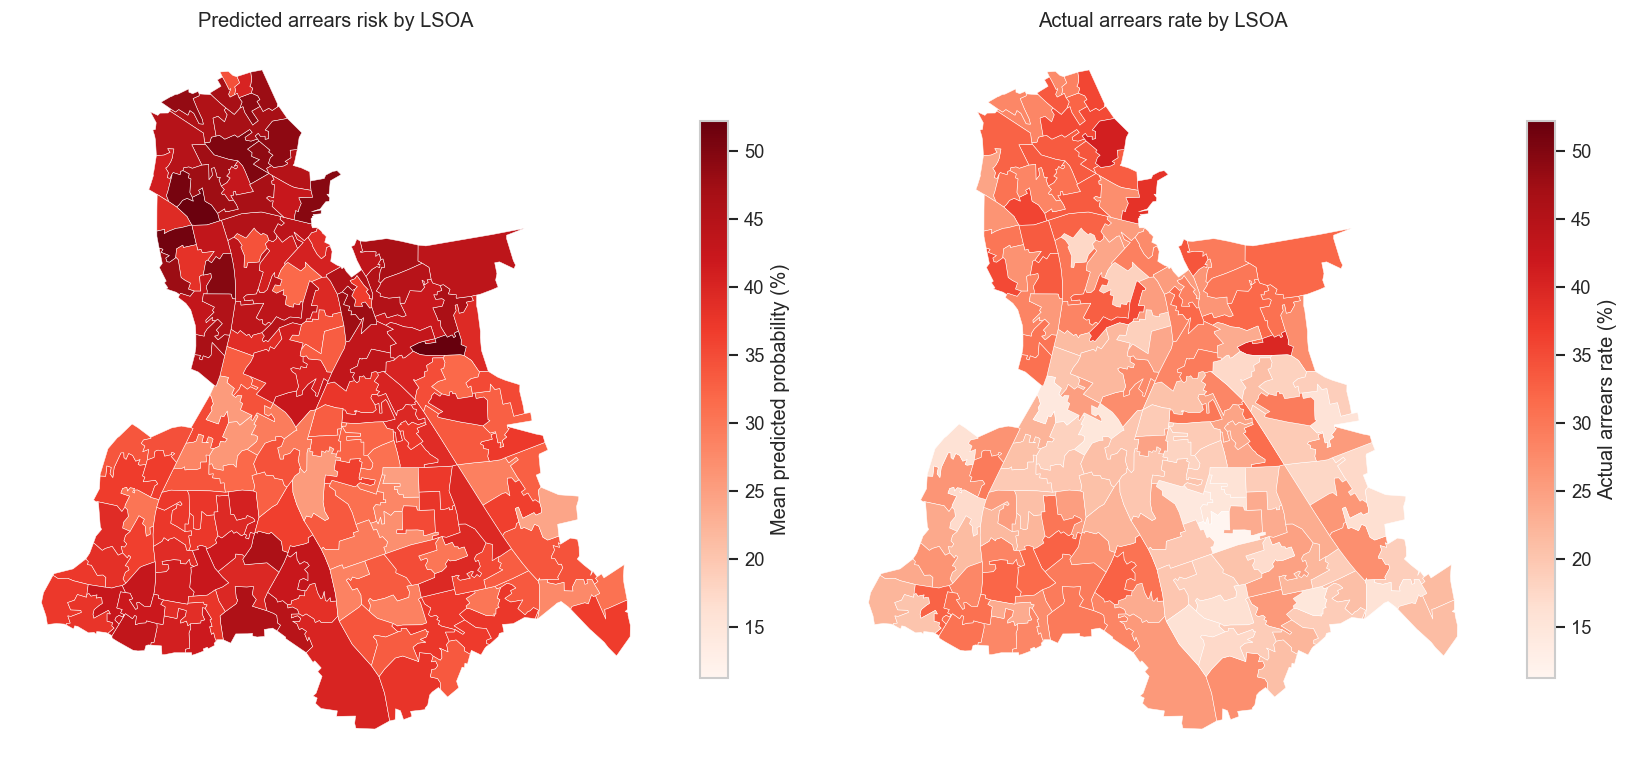

Spearman correlation (predicted vs actual arrears rate at LSOA level): ρ = 0.860, p = 1.50e-52


In [723]:
import geopandas as gpd

FULL_WIDTH = 14

# --- Out-of-sample predictions for every household ---
# Training rows: use the cross-validated predictions (each row predicted by a model that never saw it).
# Test rows: use the held-out test predictions.
# This avoids inflating apparent performance by predicting on training data with a model fitted on it.
df['pred_prob'] = np.nan
df.loc[df.index[train_idx], 'pred_prob'] = xgb_cv_probs
df.loc[df.index[test_idx], 'pred_prob'] = xgb_test_probs

lsoa_risk = df.groupby('lsoa21cd').agg(
    mean_pred_prob=('pred_prob', 'mean'),
    pct_above_50=('pred_prob', lambda x: (x > 0.5).mean() * 100),
    actual_arrears_rate=('arrears_flag', 'mean'),
    n_households=('arrears_flag', 'count'),
).reset_index()
lsoa_risk['actual_arrears_rate_pct'] = lsoa_risk['actual_arrears_rate'] * 100
lsoa_risk["mean_pred_prob"] *= 100
min_r = min(lsoa_risk["mean_pred_prob"].min(), lsoa_risk['actual_arrears_rate_pct'].min())
max_r = max(lsoa_risk["mean_pred_prob"].max(), lsoa_risk['actual_arrears_rate_pct'].max())

gdf = gpd.read_file('data/lewisham_lsoa_to_ward_best-fit_lookup.geojson')
gdf = gdf.merge(lsoa_risk, on='lsoa21cd', how='left')

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 7))

gdf.plot(column='mean_pred_prob', ax=axes[0], legend=True,
         legend_kwds={'label': 'Mean predicted probability (%)', 'shrink': 0.7},
         cmap='Reds', edgecolor='white', linewidth=0.3, vmin=min_r, vmax=max_r)
axes[0].set_title('Predicted arrears risk by LSOA')
axes[0].axis('off')

gdf.plot(column='actual_arrears_rate_pct', ax=axes[1], legend=True,
         legend_kwds={'label': 'Actual arrears rate (%)', 'shrink': 0.7},
         cmap='Reds', edgecolor='white', linewidth=0.3, vmin=min_r, vmax=max_r)
axes[1].set_title('Actual arrears rate by LSOA')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '5_6_predicted_vs_actual_maps.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation between predicted and actual at LSOA level
from scipy.stats import spearmanr
rho, p = spearmanr(lsoa_risk['mean_pred_prob'], lsoa_risk['actual_arrears_rate'])
print(f'Spearman correlation (predicted vs actual arrears rate at LSOA level): ρ = {rho:.3f}, p = {p:.2e}')


### 5.7 Key takeaways

**Model performance:**
- No meaningful difference between models — XGBoost is minimally better across all metrics. This suggests the relationship between features and arrears is largely linear, with limited non-linear signal for XGBoost to exploit.
- Sorting ability is decent but not excellent (AUC-ROC ~0.78): the model ranks arrears households above non-arrears ones correctly about 78% of the time.
- Achieving high precision and recall simultaneously is low to moderate (PR-AUC ~0.52). This is meaningfully better than random guessing (PR-AUC ≈ 0.255 given 25.5% prevalence), but reflects substantial overlap between the feature profiles of arrears and non-arrears households.
- F1 at the default 0.5 threshold is 0.55, reflecting the model's difficulty balancing recall and precision on this imbalanced data. The default 0.5 threshold is often not optimal for imbalanced data; tuning the threshold (e.g. trying 0.3 or 0.4) could improve F1, but for this task the continuous ranking matters more than performance at any single threshold.
- CV and test metrics are consistent — no sign of overfitting.

**SHAP vs Spearman:**
- There is considerable overlap between the two analyses. The strongest Spearman correlates with arrears — age, universal credit, income after costs, fuel poverty, FSM eligibility — all appear among the most important SHAP features. The broad picture is consistent: both methods identify the same core signal.
- The interesting cases are the divergences. Monthly rent and IMD rank both had weak or near-zero Spearman correlation with arrears, yet appear as meaningful predictors in the model. The explanation is the same for both: Spearman measures a bivariate monotonic relationship (does arrears go up as this feature goes up, ignoring everything else?), while the model sees all features simultaneously and can learn conditional patterns. Monthly rent in isolation doesn't sort neatly along an arrears axis — high rent with low income is risky, high rent with adequate income is not — but alongside income and benefits, the model can use those conditional relationships. IMD rank similarly may add information conditional on other features (e.g. within a ward, or after accounting for household characteristics, the area-level deprivation signal becomes informative). A feature with no bivariate association can still be predictive in a multivariate model because its signal is conditional on other features.

**Geographic aggregation (sanity check):**
- Aggregating household-level predictions to LSOA level and comparing against actual arrears rates gives a Spearman correlation of ρ = 0.86 — the two maps look similar in pattern but with higher arrear risk predictions. This is not surprising: the model includes ward which correlates with arrears rate. More precisely, if a household is in an area with a high arrears rate, it is statistically likely to be at risk itself. In fact, using the LSOA arrears rate directly as a feature would likely make the model much stronger, but this would be data leakage: the rate is computed from `arrears_flag`, the target variable. A leave-one-out construction (each household's LSOA rate excluding that household) would remove the direct contamination, but the feature would still dominate the model and overshadow all household-level predictors — obscuring the very patterns that are most actionable from a policy perspective. The high spatial correspondence is best read as a sanity check: the model's household-level predictions aggregate coherently to area level. If the correlation were low, *that* would be worth investigating.


---
## 6. Prioritisation

### 6.1 Approach

Apply the XGBoost classifier to all households not currently in arrears. Each receives a predicted probability (0–1) serving as a continuous risk score. Rank by this score and select the top 10% (~1,340 of ~13,280 non-arrears households) as the candidate intervention list.

### 6.2 Model precision

The model is a screening tool, it is not precise itself. PR-AUC ~0.52 and F1 ~0.53 mean the ranking is better than random, but the top 10% will include false positives (households flagged that are not heading for arrears) and miss some true positives. If building an intervention based no these precisions, we need to expect imprecision and build in room for human judgement.

### 6.3 Equity considerations

Prioritisation need not be determined by the model alone. Explicit equity criteria can be layered on top:

- **Presence of children**: proxied by `household_type` (lone parent, couple with children) and `fsm_eligible`
- **Disability**: `disability`
- **Depth of poverty**: `fuel_poverty`, `food_poverty`

These reflect value judgements about who deserves support.

### 6.4 Composite priority score

A simple framework:

```
priority = predicted_probability + equity_weights
```

Equity weights are explicitly defined — e.g. +0.05 for households with children, +0.05 for disability. The weights are auditable and adjustable: the council decides what matters and by how much, and those decisions are visible rather than implicit.

### 6.5 Severity as a future extension

The prioritisation above is based on risk alone — who is likely to fall into arrears. A severity model (predicting how much arrears a household might accumulate) could add a second dimension. This would be relevant if the policy goal shifts from *preventing arrears* to *preventing high arrears* — for example, if the council wants to identify households at risk of accumulating large debts that become harder to recover from. In that framing, two households with similar risk scores but different predicted severity would warrant different levels of intervention.

---
## Future Work

### 1. Temporal validation

Temporal validation would test whether the relationships the model has learned — e.g. "fuel poverty + UC + lone parent = elevated risk" — are stable over time, or whether they are tied to conditions specific to this snapshot (a cost-of-living spike, a policy change, seasonal patterns in energy bills, etc.). A random train/test split of a single snapshot does not test generalisation to an unseen *point in time*.

One simple method would require two historical snapshots, both labelled. Then train on the earlier snapshot (using only its features and its `arrears_flag`), generate predictions for households in the later snapshot, then compare those predictions against the later snapshot's actual labels. This is the real-world deployment question asked as rigorously as the data allows: if the council had been given a priority list based on data from six months ago, would that list still reflect who is actually in arrears today?

### 2. Model without ward

Ward is a notable SHAP predictor, but if it is dropped and AUC barely moves, that is reassuring because it implies that the model is learning from household characteristics, which are more relevant for policy. However, if AUC drops substantially, it means geography is doing the heavy lifting, which raises questions about what the model is really capturing and whether the predictions generalise to new areas or time periods.

### 3. Threshold tuning

The default 0.5 threshold is arbitrary. A sweep to find the threshold that maximises F1 — or that achieves a specific recall target, e.g. "catch 80% of arrears cases" — would make the model more operationally useful. It also connects directly to the prioritisation question: the council probably has a specific capacity constraint, and the threshold should reflect that.

### 4. Calibrating composite priority score

The composite priority score in Section 6.4 is `predicted_probability + equity_weights`. For this to be meaningful, the probabilities need to be well-calibrated — a score of 0.4 should mean roughly a 40% chance of arrears. If the model is systematically over- or under-confident in certain ranges, adding a fixed equity weight like +0.05 has inconsistent effects across the scale. A calibration plot (predicted probability vs observed frequency) is quick to produce and would either validate the approach or show where correction is needed.